In [93]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import data_clean_utils
from scipy.stats import chi2_contingency, f_oneway, jarque_bera, probplot
import plotly.express as px
from matplotlib.gridspec import GridSpec

In [94]:
df = pd.read_csv('train.csv')

df.sample(6)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
16647,0x1c8a,MUMRES14DEL01,32,4.8,19.181300,72.836191,19.251300,72.906191,14-03-2022,22:10:00,22:20:00,conditions Stormy,Low,2,Drinks,scooter,0,No,NaN,(min) 20
9806,0xa08e,MUMRES07DEL01,20,4.9,19.091458,72.827808,19.101458,72.837808,05-03-2022,08:10:00,08:25:00,conditions Sandstorms,Low,1,Drinks,motorcycle,0,No,Metropolitian,(min) 12
33670,0x1434,HYDRES09DEL02,26,4.5,17.431668,78.408321,17.511668,78.488321,23-03-2022,18:35:00,18:45:00,conditions Sunny,Medium,2,Buffet,scooter,1,No,Metropolitian,(min) 10
39869,0x6582,INDORES06DEL01,27,4.8,22.728163,75.884212,22.768163,75.924212,03-04-2022,16:15:00,16:25:00,conditions Cloudy,Medium,2,Buffet,electric_scooter,0,No,Metropolitian,(min) 13
32149,0xe1b8,ALHRES02DEL01,35,4.8,25.453436,81.833167,25.563436,81.943167,16-02-2022,18:10:00,18:15:00,conditions Fog,Medium,2,Drinks,motorcycle,1,No,Metropolitian,(min) 44
7380,0x3a74,SURRES010DEL01,27,4.8,21.171060,72.789292,21.211060,72.829292,03-04-2022,14:00:00,14:05:00,conditions Cloudy,High,1,Buffet,motorcycle,0,No,Urban,(min) 24


In [95]:
from data_clean_utils import perform_data_cleanining
perform_data_cleanining(df)

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


In [96]:
df_final = pd.read_csv('cleaned-data.csv')
df_final

,rider_id,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,24,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,33,BANG,25,3,friday,0,5.0,19.0,evening,20.183530
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,26,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,21,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,32,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,36,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,16,CHEN,11,3,friday,0,15.0,23.0,night,4.657195
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,26,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393


## Prelimnary Analyasis

In [97]:
df_final.isna().sum()

,0
rider_id,0
rider_age,1854
ratings,1908
restaurant_latitude,3630
restaurant_longitude,3630
delivery_latitude,3630
delivery_longitude,3630
order_date,0
weather,525
traffic,510


In [98]:
df_final.isna().sum().sum()

np.int64(28646)

In [99]:
missing_rows = (
    df_final
    .isna()
    .any(axis=1)
    .sum()
)

print(f'total missing rows {missing_rows}')
print(f'it is {missing_rows/df_final.shape[0] * 100: .2f}% of the total rows')

total missing rows 7438
it is  16.35% of the total rows


In [100]:
df_final.duplicated().sum()

np.int64(0)

In [101]:
df_final.dtypes

,0
rider_id,object
rider_age,float64
ratings,float64
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
order_date,object
weather,object
traffic,object


In [102]:
num_cols = df_final.columns[[1,2,3,4,5,6,16,22,25]].tolist()
cat_cols = [col for col in df_final.columns.tolist() if col not in num_cols]

print(f'there are {len(num_cols)} numerical columns and {len(cat_cols)} categorical columns in the data')

there are 9 numerical columns and 17 categorical columns in the data


In [103]:
num_cols


['rider_age',
 'ratings',
 'restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'time_taken',
 'pickup_time_minutes',
 'distance']

In [104]:
cat_cols

['rider_id',
 'order_date',
 'weather',
 'traffic',
 'vehicle_condition',
 'type_of_order',
 'type_of_vehicle',
 'multiple_deliveries',
 'festival',
 'city_type',
 'city_name',
 'order_day',
 'order_month',
 'order_day_of_week',
 'is_weekend',
 'order_time_hour',
 'order_time_of_day']

In [105]:
df_final[num_cols].describe()

,rider_age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,time_taken,pickup_time_minutes,distance
count,43648.000000,43594.000000,41872.000000,41872.000000,41872.000000,41872.000000,45502.000000,43862.000000,41872.000000
mean,29.555008,4.635287,18.913696,76.921664,18.977356,76.985325,26.297591,9.989399,9.719296
std,5.761482,0.313827,5.467265,3.503107,5.469056,3.503260,9.386419,4.087516,5.602890
min,20.000000,2.500000,9.957144,72.768726,9.967144,72.778726,10.000000,5.000000,1.465067
25%,25.000000,4.500000,12.986047,73.897902,13.065996,73.940327,19.000000,5.000000,4.657655
50%,30.000000,4.700000,19.065838,76.618203,19.124049,76.662620,26.000000,10.000000,9.193014
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,32.000000,15.000000,13.680920
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,54.000000,15.000000,20.969489


In [106]:
(
    df_final
    .assign(**{
        col: df_final[col].astype('object')
        for col in cat_cols

    })
    .describe(include='object')
    .T
)

,count,unique,top,freq
rider_id,45502,1320,PUNERES01DEL01,67
order_date,45502,44,2022-03-15,1190
weather,44977,6,fog,7654
traffic,44992,4,low,15477
vehicle_condition,45502,4,2,15034
type_of_order,45502,4,snack,11512
type_of_vehicle,45502,4,motorcycle,26427
multiple_deliveries,44509.0,4.0,1.0,28109.0
festival,45274,2,no,44380
city_type,44304,3,metropolitian,34029


### Missing value analysis 

<Axes: >

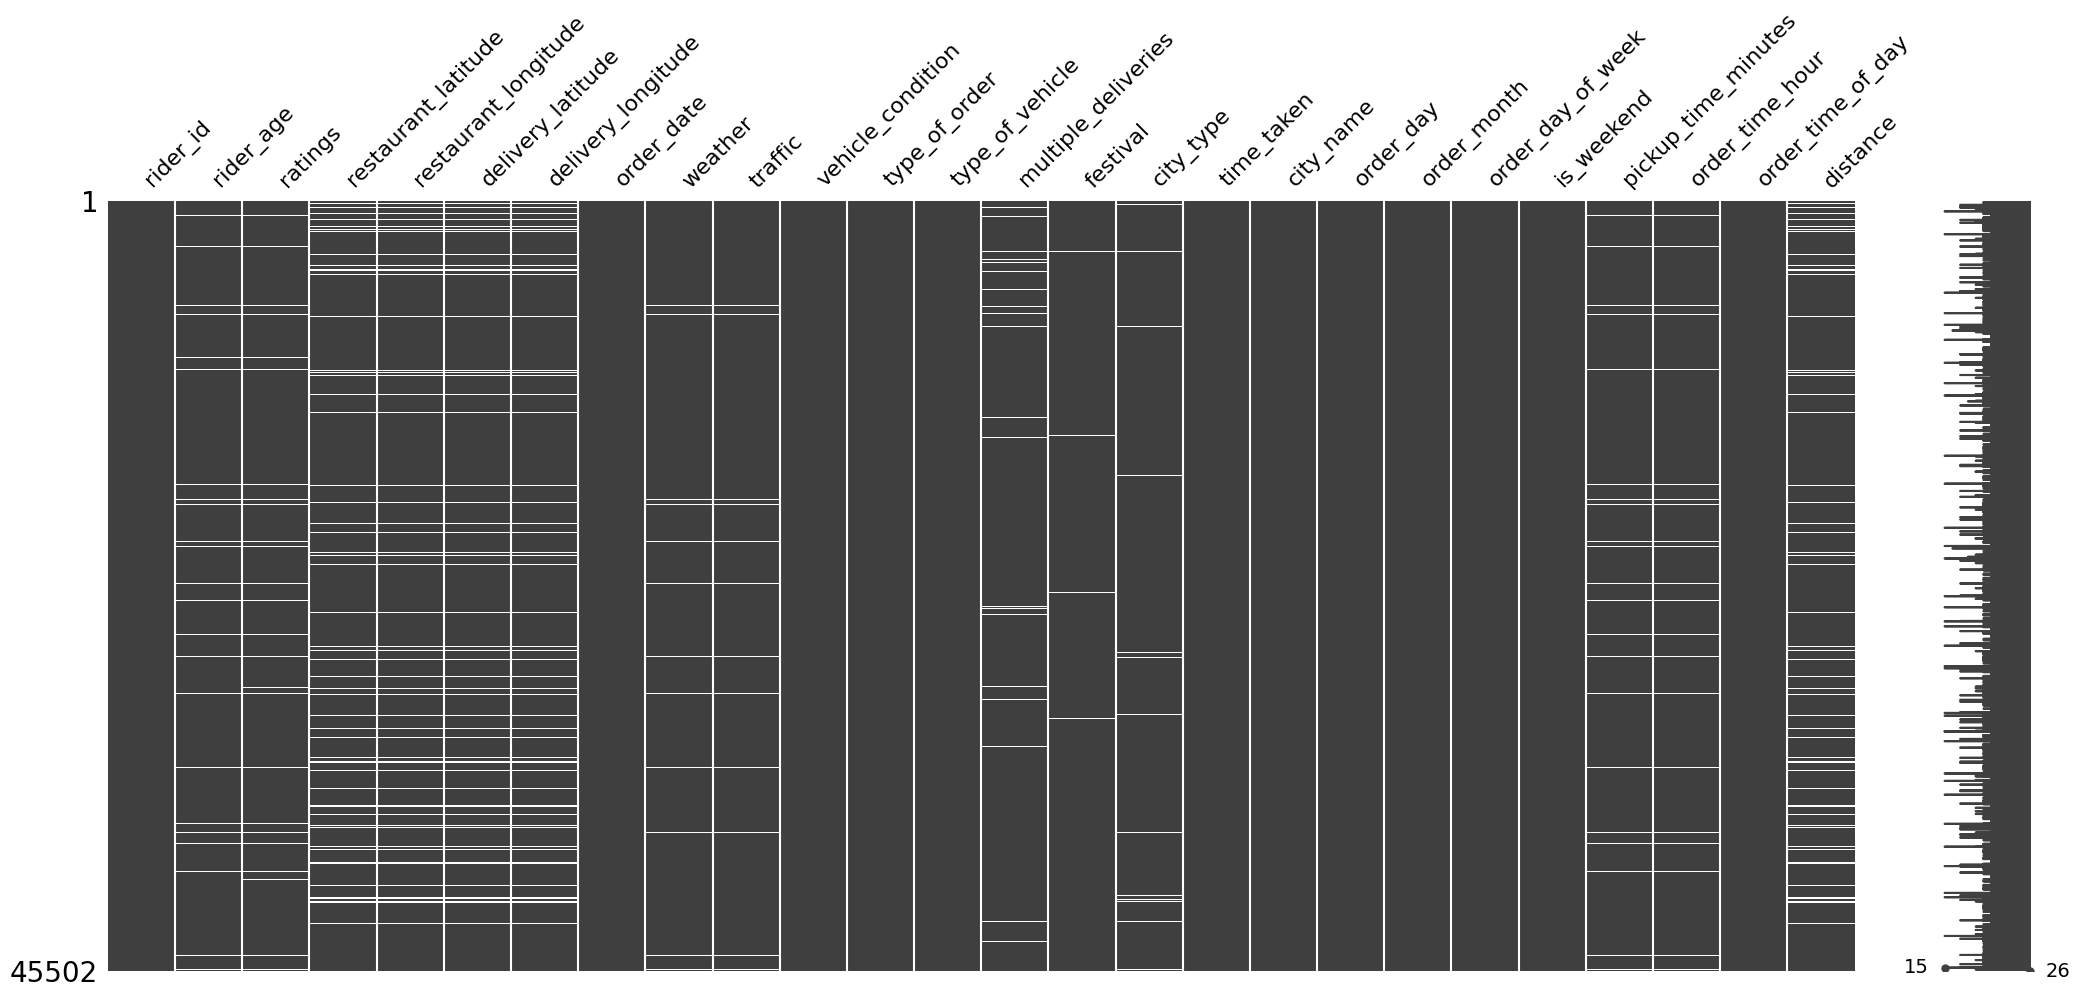

In [107]:
import missingno as msno
msno.matrix(df_final)

<Axes: >

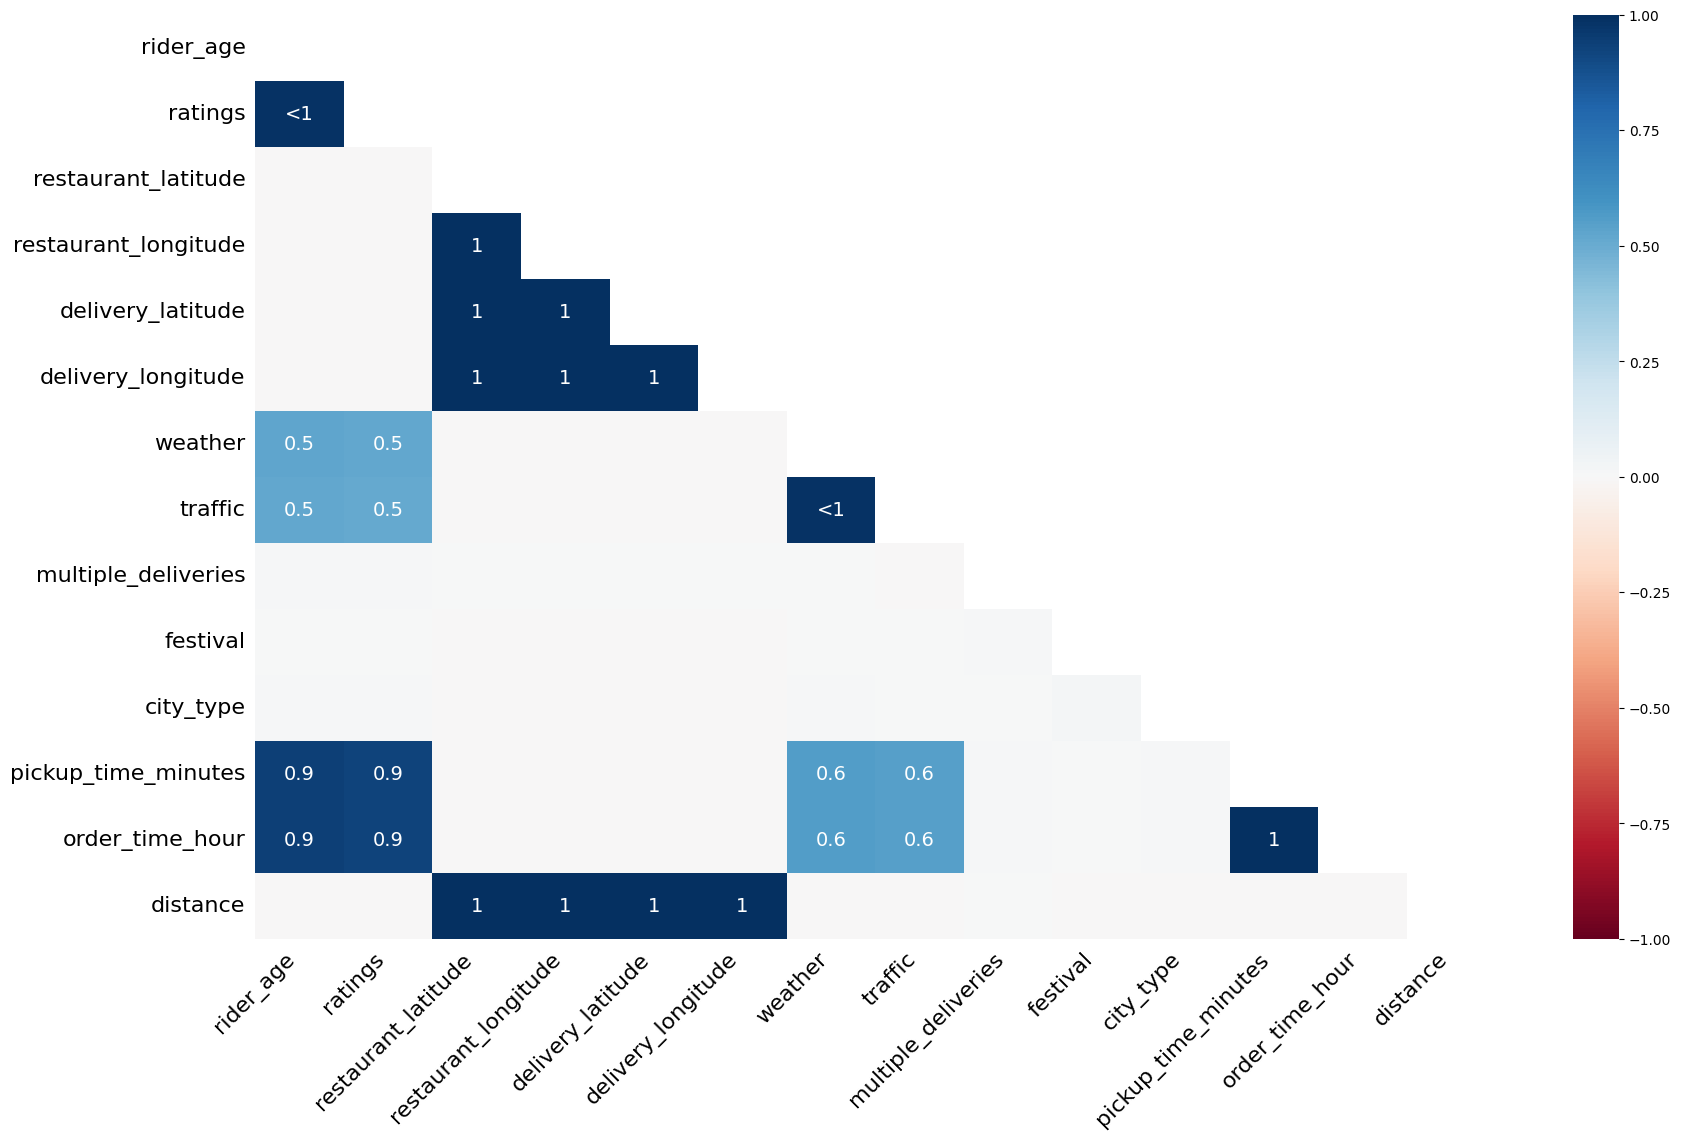

In [108]:
msno.heatmap(df_final)

<Axes: >

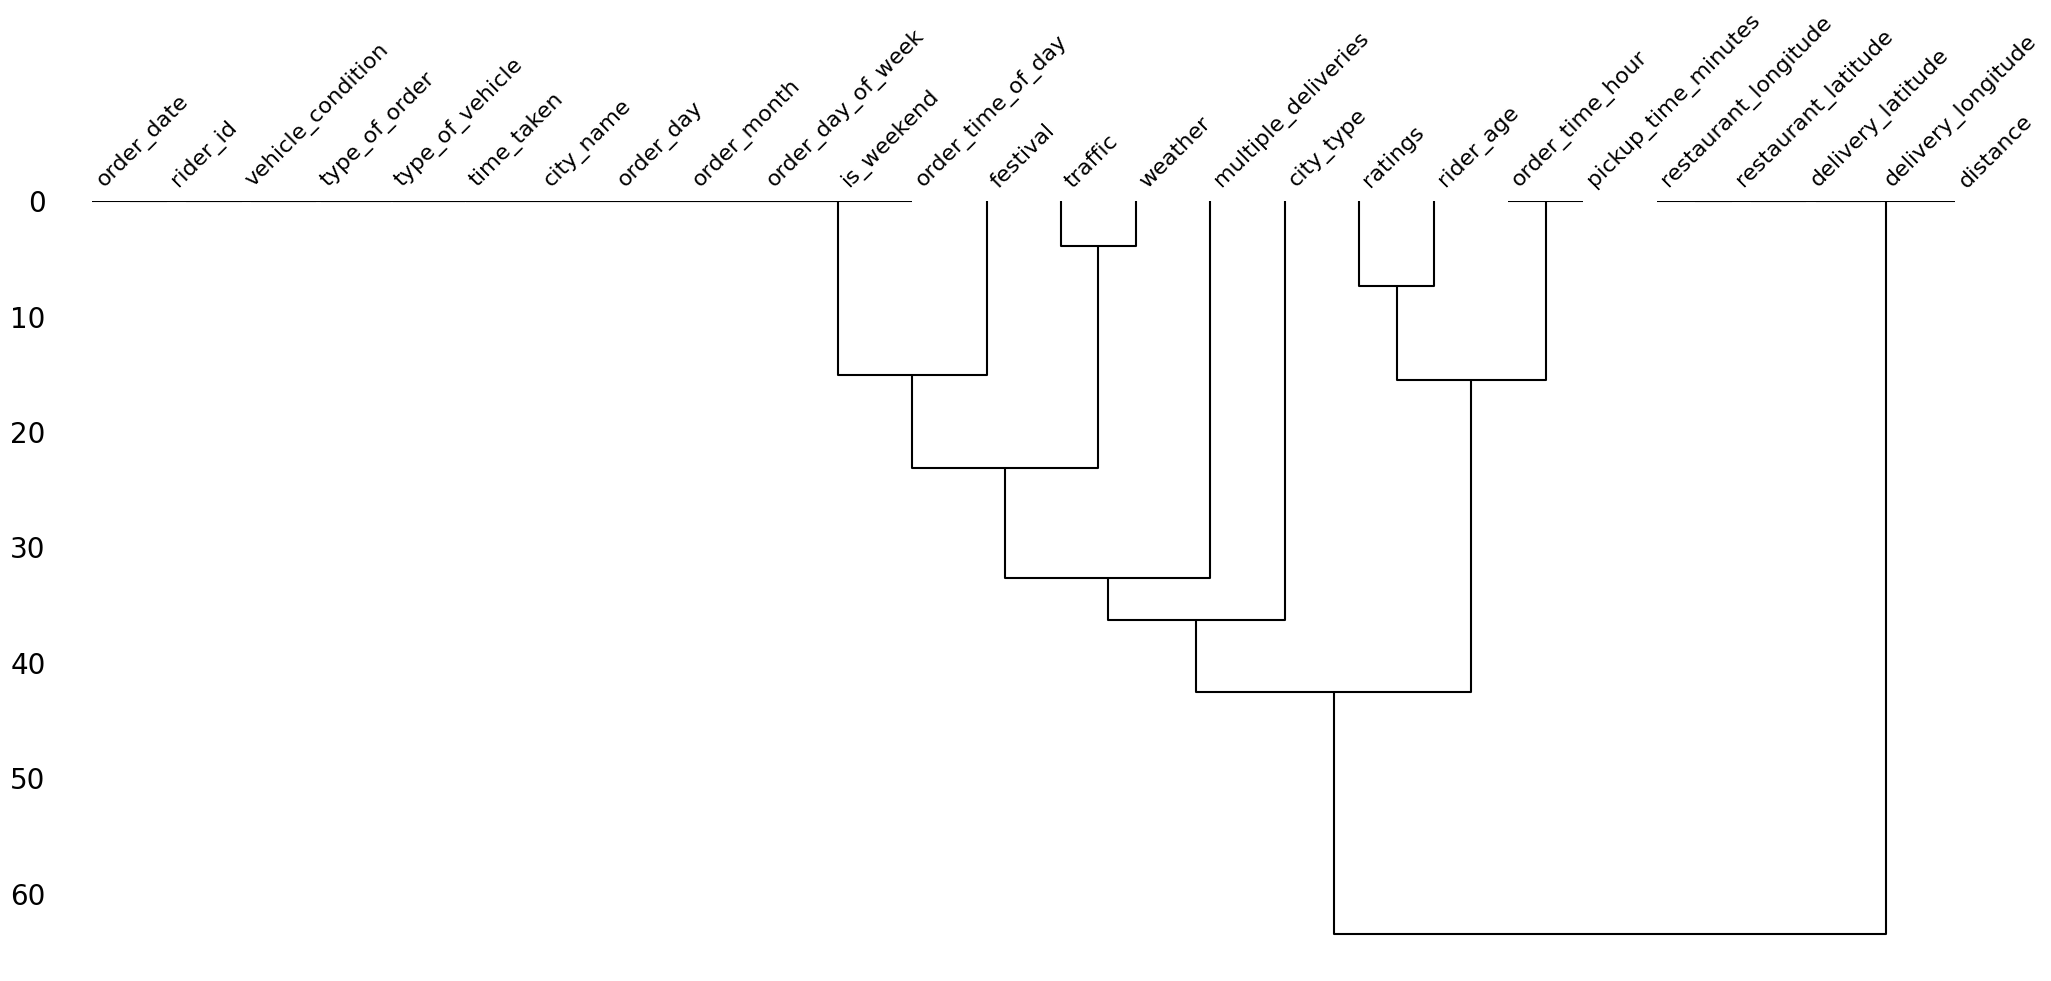

In [109]:
msno.dendrogram(df_final)

## Functions to perform analysis 

In [110]:
def numerical_analysis(datafrmae, column_name, cat_col=None, bins='auto'):
    fig = plt.figure(figsize=(15,10))

    grid = GridSpec(nrows=2, ncols=2, figure=fig)

    ax1 = fig.add_subplot(grid[0, 0])
    ax2 = fig.add_subplot(grid[0, 1])
    ax3 = fig.add_subplot(grid[1, :])

    sns.kdeplot(data=datafrmae, x=column_name, hue=cat_col, ax=ax1)
    sns.boxplot(data=datafrmae, x=column_name, hue=cat_col, ax=ax2)
    sns.histplot(data=datafrmae, x=column_name, hue=cat_col, kde=True, ax=ax3)
    
    plt.tight_layout()
    plt.show()


def numerical_categorical_analysis(dataframe, cat_column_1, num_column):
    fig = plt.figure(figsize=(15,9))
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 7.5))

    sns.barplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[0])
    sns.boxplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax1[1])
    sns.violinplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[0])
    sns.stripplot(data=dataframe, x=cat_column_1, y=num_column, ax=ax2[1])

    plt.tight_layout()
    plt.show()


def categorical_analysis(dataframe, column_name):
    display(
        pd.DataFrame({
            'count': dataframe[column_name].value_counts(),
            'percentage': (
                dataframe[column_name]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .astype('str')
                .add('%')
            )
            
        })
    )
    print('*' * 50)

    unique_category = dataframe[column_name].unique().tolist()
    number_of_categories = dataframe[column_name].nunique()
    print(f'the unique categories in {column_name} columns are {unique_category}')

    print('*' * 50)
    print(f'the number of categories in {column_name} columns are {number_of_categories}')

    sns.countplot(data=dataframe, x=column_name)
    plt.xticks(rotation=45)
    plt.show()


def multivariate_analysis(dataframe, num_col, cat_col1, cat_col2):
    fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 7.5))

    sns.barplot(data=dataframe, x=cat_col1, y=num_col, hue=cat_col2, ax=ax1[0])
    sns.boxplot(data=dataframe, x=cat_col1, y=num_col, hue=cat_col2, gap=.1, ax=ax1[1])

    sns.violinplot(data=dataframe, x=cat_col1, y=num_col, hue=cat_col2, gap=.1, ax=ax2[0])
    sns.stripplot(data=dataframe, x=cat_col1, y=num_col, hue=cat_col2, dodge=True, ax=ax2[1])

    plt.tight_layout()
    plt.show()


def chi_2_test(datafrmae, col1, col2, alpha=.05):
    data=(
        datafrmae.loc[:, [col1, col2]]
        .dropna()
    )

    contingency_table = pd.crosstab(data[col1], data[col2])
    _, p_val, _, _ = chi2_contingency(contingency_table)
    print(p_val)

    if p_val <= alpha:
        print(f'reject the null hypothesis. there is a significant assosiation betweem {col1} and {col2}')
    else :
        print(f'fail to reject the null hypothesis. there is no significant assosiation betweem {col1} and {col2}')



def anova_test(dataframe, num_col, cat_col, alpha=.05):
    data=(
        dataframe.loc[:, [num_col, cat_col]]
        .dropna()
    )
    cat_groups = data.groupby(cat_col)
    groups = [group[num_col].values for _, group in cat_groups]

    f_stat, p_val = f_oneway(*groups)
    print(p_val)

    if p_val <= alpha:
        print(f'reject the null hypothesis. there is a significant assosiation betweem {num_col} and {cat_col}')
    else :
        print(f'fail to reject the null hypothesis. there is no significant assosiation betweem {num_col} and {cat_col}')


def test_for_normality(dataframe, column_name, alpha=.05):
    data = dataframe[column_name]
    print('jarque_bera test for normality')

    _, p_val = jarque_bera(data)
    print(p_val)
    if p_val <= alpha:
        print(f'reject the null hypothesis. the data is not normally distributed')
    else :
        print(f'fail to reject the null hypothesis. data is normally distributed', end='\n\n')



## Column wise analysis 

In [111]:
df_final.columns

Index(['rider_id', 'rider_age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance'],
      dtype='object')

## Time Taken

In [112]:
df_final['time_taken'].dtype

dtype('int64')

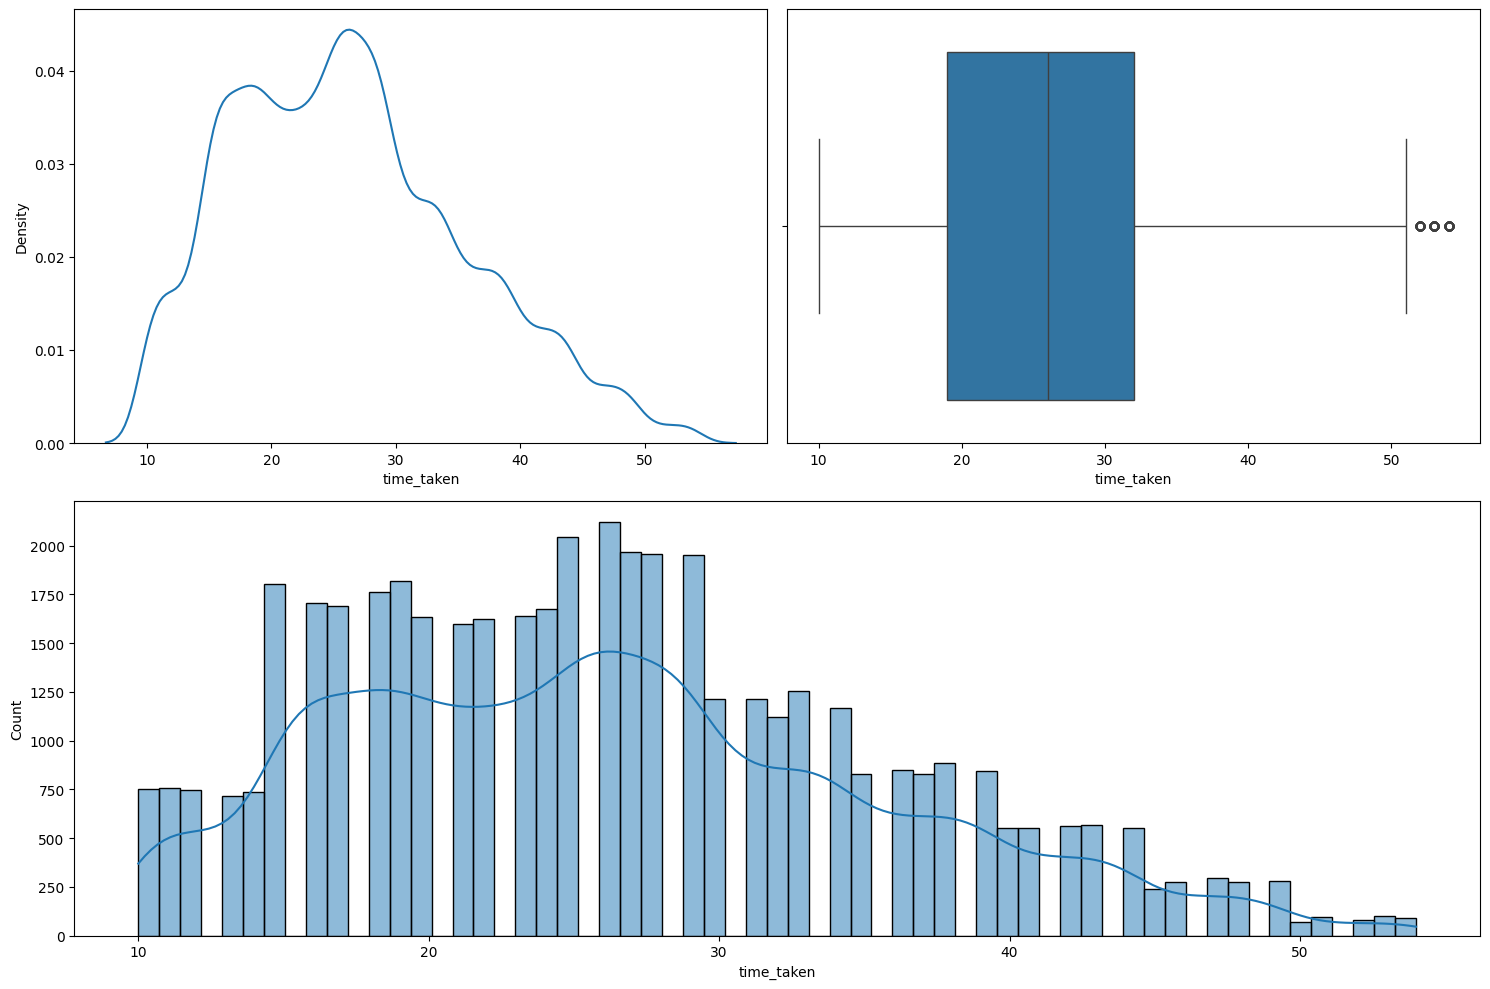

In [113]:
numerical_analysis(df_final, 'time_taken', bins=10)

**Obsevations**
1. target columns skewed hai
2. 2-peaks (17-18 and 27-28 ke ass pas)
3. kuch extream points bhi hai pr outlier nhi lg rhe hai 

((array([-4.16995158, -3.96319864, -3.8504397 , ...,  3.8504397 ,
          3.96319864,  4.16995158]),
  array([10, 10, 10, ..., 54, 54, 54])),
 (np.float64(9.264045148605504),
  np.float64(26.297591314667482),
  np.float64(0.9868843995770019)))

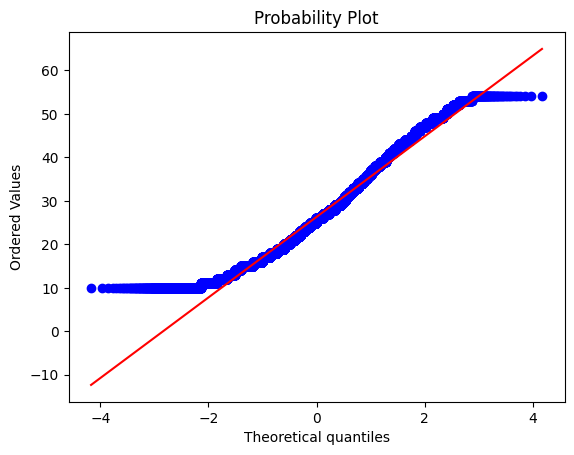

In [114]:
probplot(df_final['time_taken'], plot=plt)

In [115]:
test_for_normality(df_final, 'time_taken')

jarque_bera test for normality
0.0
reject the null hypothesis. the data is not normally distributed


In [116]:
target_25_per, target_75_per = np.percentile(df_final['time_taken'], [25, 75])

iqr = target_75_per - target_25_per

upper_bound = target_75_per + 1.5*(iqr)

df_final.loc[(df_final['time_taken'] > upper_bound), 'traffic'].value_counts()

,count
traffic,
jam,241
high,24


In [117]:
df_final.loc[(df_final['time_taken'] > upper_bound), 'weather'].value_counts()

,count
weather,
fog,57
sunny,51
windy,44
cloudy,44
stormy,37
sandstorms,32


In [118]:
avg_distance = df_final.loc[:, 'distance'].mean()
avg_distance_extream = df_final.loc[(df_final['time_taken'] > upper_bound), 'distance'].mean()

print(avg_distance, avg_distance_extream)

9.719296323199579 13.29215081388658


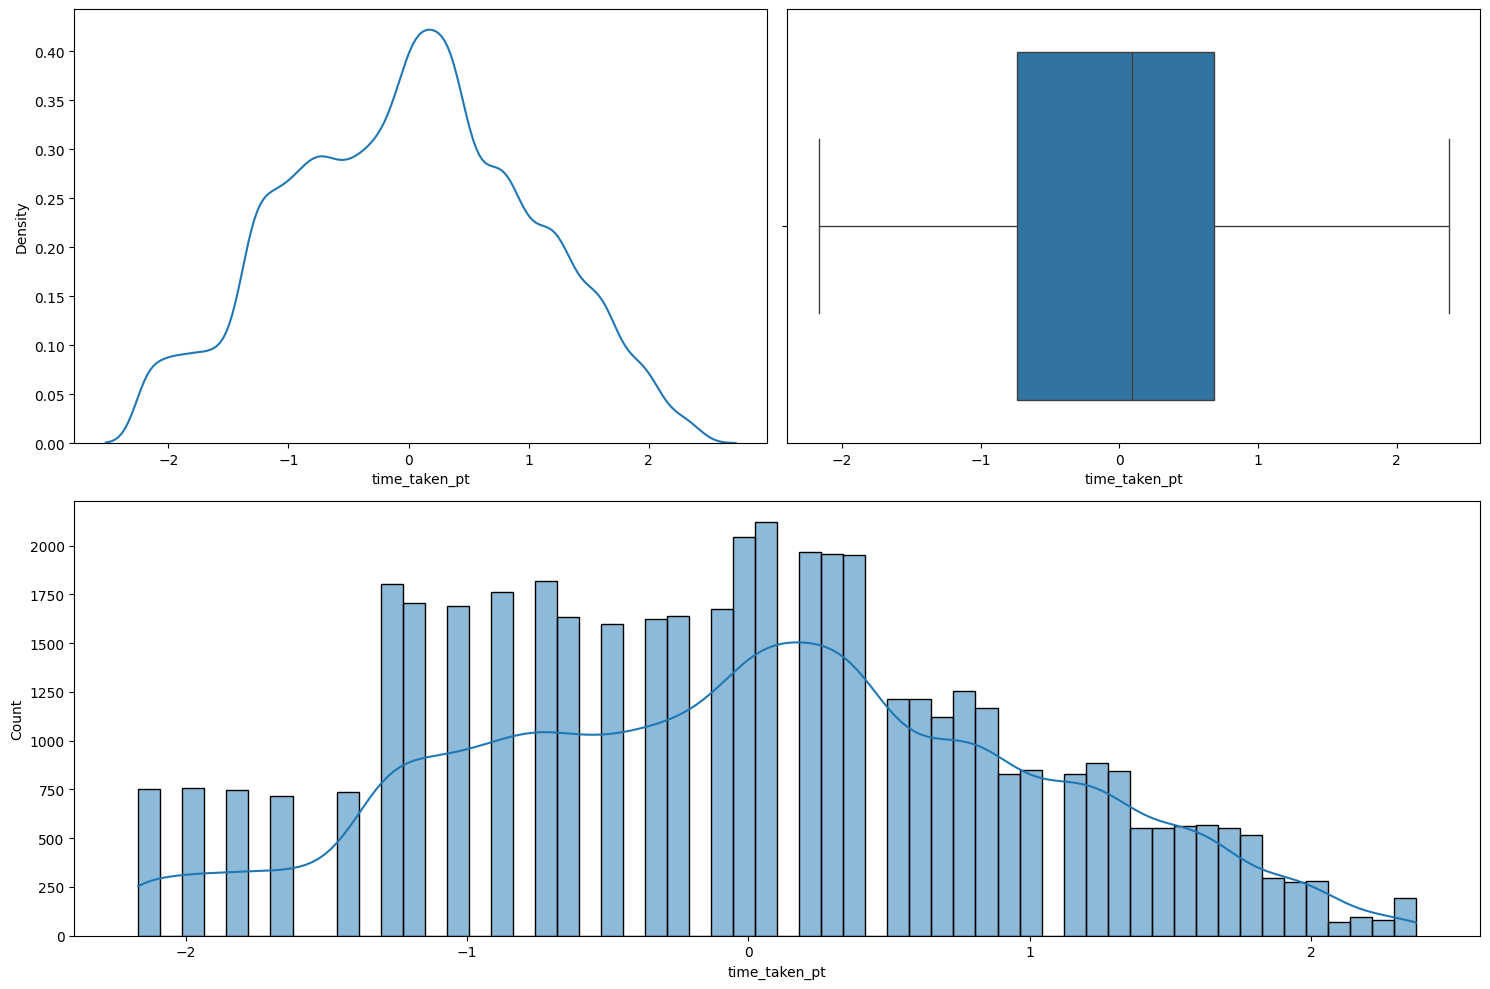

In [119]:
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

df_final['time_taken_pt'] = pt.fit_transform(df_final[['time_taken']])

numerical_analysis(df_final, 'time_taken_pt', bins=10)

((array([-4.16995158, -3.96319864, -3.8504397 , ...,  3.8504397 ,
          3.96319864,  4.16995158]),
  array([-2.16837776, -2.16837776, -2.16837776, ...,  2.37354703,
          2.37354703,  2.37354703])),
 (np.float64(0.9953574239385325),
  np.float64(1.101289590841088e-15),
  np.float64(0.9952675528665528)))

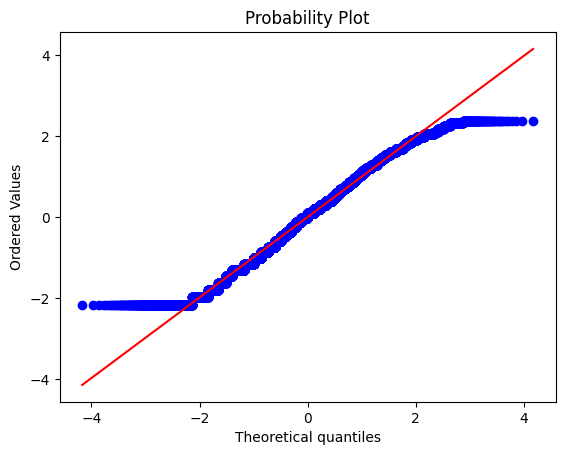

In [120]:
probplot(df_final['time_taken_pt'], plot=plt)

### Rider_ID

In [121]:
df_final['rider_id'].dtype

dtype('O')

In [122]:
df_final[['rider_id', 'rider_age', 'ratings']]

,rider_id,rider_age,ratings
0,INDORES13DEL02,37.0,4.9
1,BANGRES18DEL02,34.0,4.5
2,BANGRES19DEL01,23.0,4.4
3,COIMBRES13DEL02,38.0,4.7
4,CHENRES12DEL01,32.0,4.6
...,...,...,...
45497,JAPRES04DEL01,30.0,4.8
45498,AGRRES16DEL01,21.0,4.6
45499,CHENRES08DEL03,30.0,4.9
45500,COIMBRES11DEL01,20.0,4.7


In [123]:
rider_id_group = df_final[['rider_id', 'rider_age', 'ratings']].groupby('rider_id')
rider_id_group.head(5).sort_values('rider_id')

,rider_id,rider_age,ratings
92,AGRRES010DEL01,34.0,4.7
7738,AGRRES010DEL01,21.0,4.7
4554,AGRRES010DEL01,38.0,4.7
12416,AGRRES010DEL01,34.0,4.5
13223,AGRRES010DEL01,39.0,4.4
...,...,...,...
861,VADRES20DEL03,35.0,4.8
9792,VADRES20DEL03,30.0,4.6
9753,VADRES20DEL03,38.0,4.8
5094,VADRES20DEL03,35.0,4.9


In [124]:
df_final[['rider_id', 'rider_age', 'ratings']].dropna().duplicated(keep=False).sum()

np.int64(10155)

In [125]:
(
    df_final.loc[(df_final[['rider_id', 'rider_age', 'ratings']].duplicated(keep=False)), ['rider_id', 'rider_age', 'ratings']]
    .dropna()
    .sort_values(['rider_id'])
)

,rider_id,rider_age,ratings
18533,AGRRES03DEL02,24.0,4.9
40285,AGRRES03DEL02,24.0,4.9
28473,AGRRES03DEL03,30.0,4.7
26275,AGRRES03DEL03,30.0,4.7
36131,AGRRES06DEL02,36.0,4.9
...,...,...,...
12742,VADRES20DEL02,28.0,4.5
5094,VADRES20DEL03,35.0,4.9
17963,VADRES20DEL03,35.0,4.9
21957,VADRES20DEL03,37.0,4.9


- reliable nhi hai imputation ke liye kyuki kuch me to ratings rider age ki same values hai pr sb me nhi hai jesa ki uper dekha tha 

### rider_age

In [126]:
df_final['rider_age'].dtype

dtype('float64')

In [127]:
df_final['rider_age'].describe()

,rider_age
count,43648.000000
mean,29.555008
std,5.761482
min,20.000000
25%,25.000000
50%,30.000000
75%,35.000000
max,39.000000


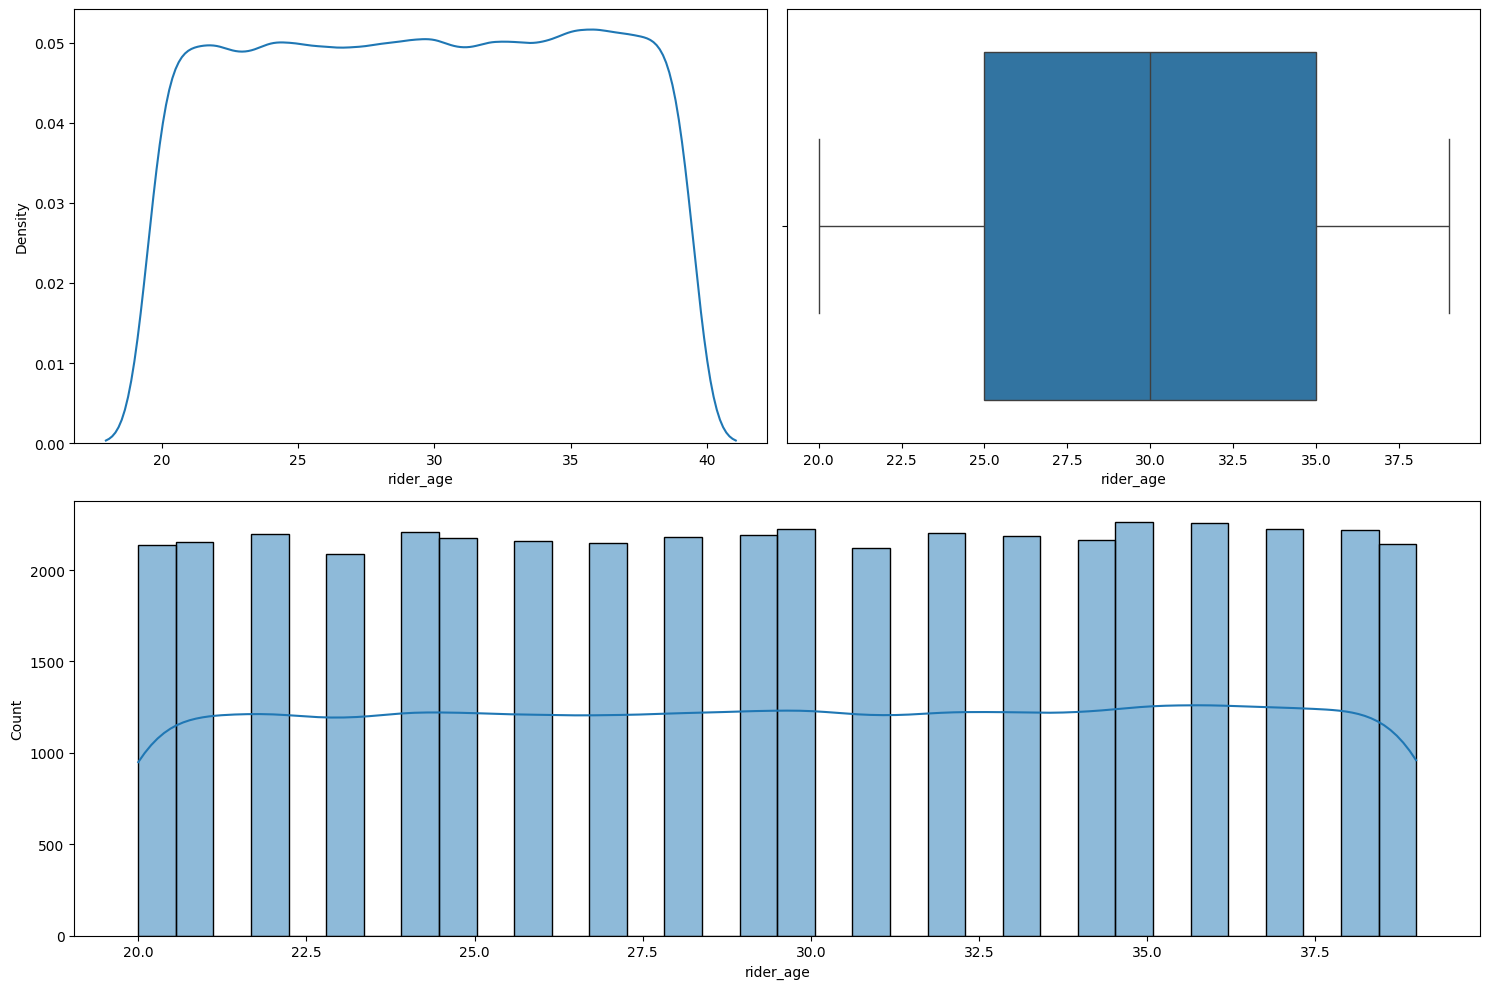

In [128]:
numerical_analysis(df_final, 'rider_age')

<Axes: xlabel='rider_age', ylabel='time_taken'>

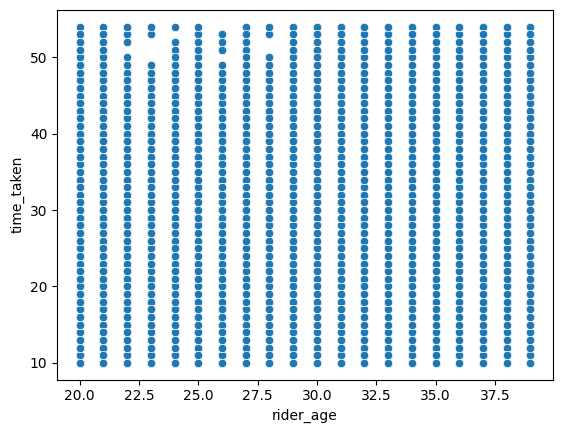

In [129]:
sns.scatterplot(df_final, x='rider_age', y='time_taken')

- sb age groups me varieations barabar hi hai 

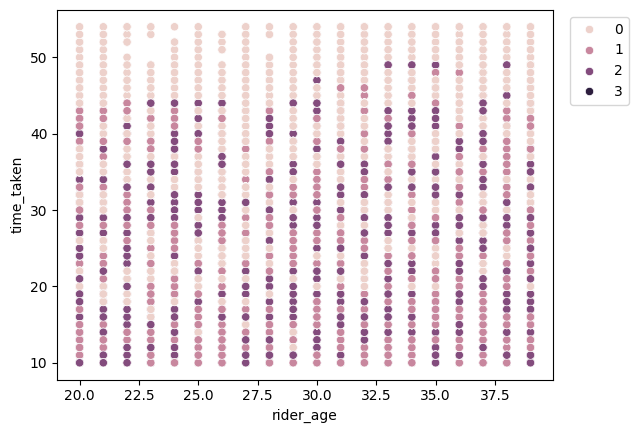

In [130]:
sns.scatterplot(df_final, x='rider_age', y='time_taken', hue='vehicle_condition')
plt.legend(bbox_to_anchor=(1.02, 1), loc=2)

- longer deliveries k liye 0 wala vehicle prefer kiya hai 

<Axes: xlabel='type_of_vehicle', ylabel='rider_age'>

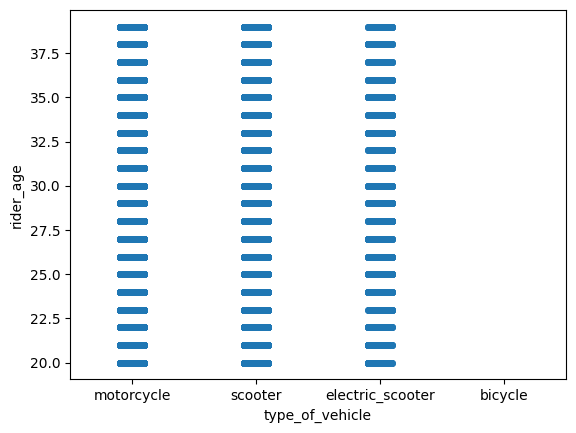

In [131]:
sns.stripplot(df_final, x='type_of_vehicle', y='rider_age')

### Ratings

In [132]:
df_final['ratings'].dtype

dtype('float64')

In [133]:
df_final['ratings'].describe()

,ratings
count,43594.000000
mean,4.635287
std,0.313827
min,2.500000
25%,4.500000
50%,4.700000
75%,4.900000
max,5.000000


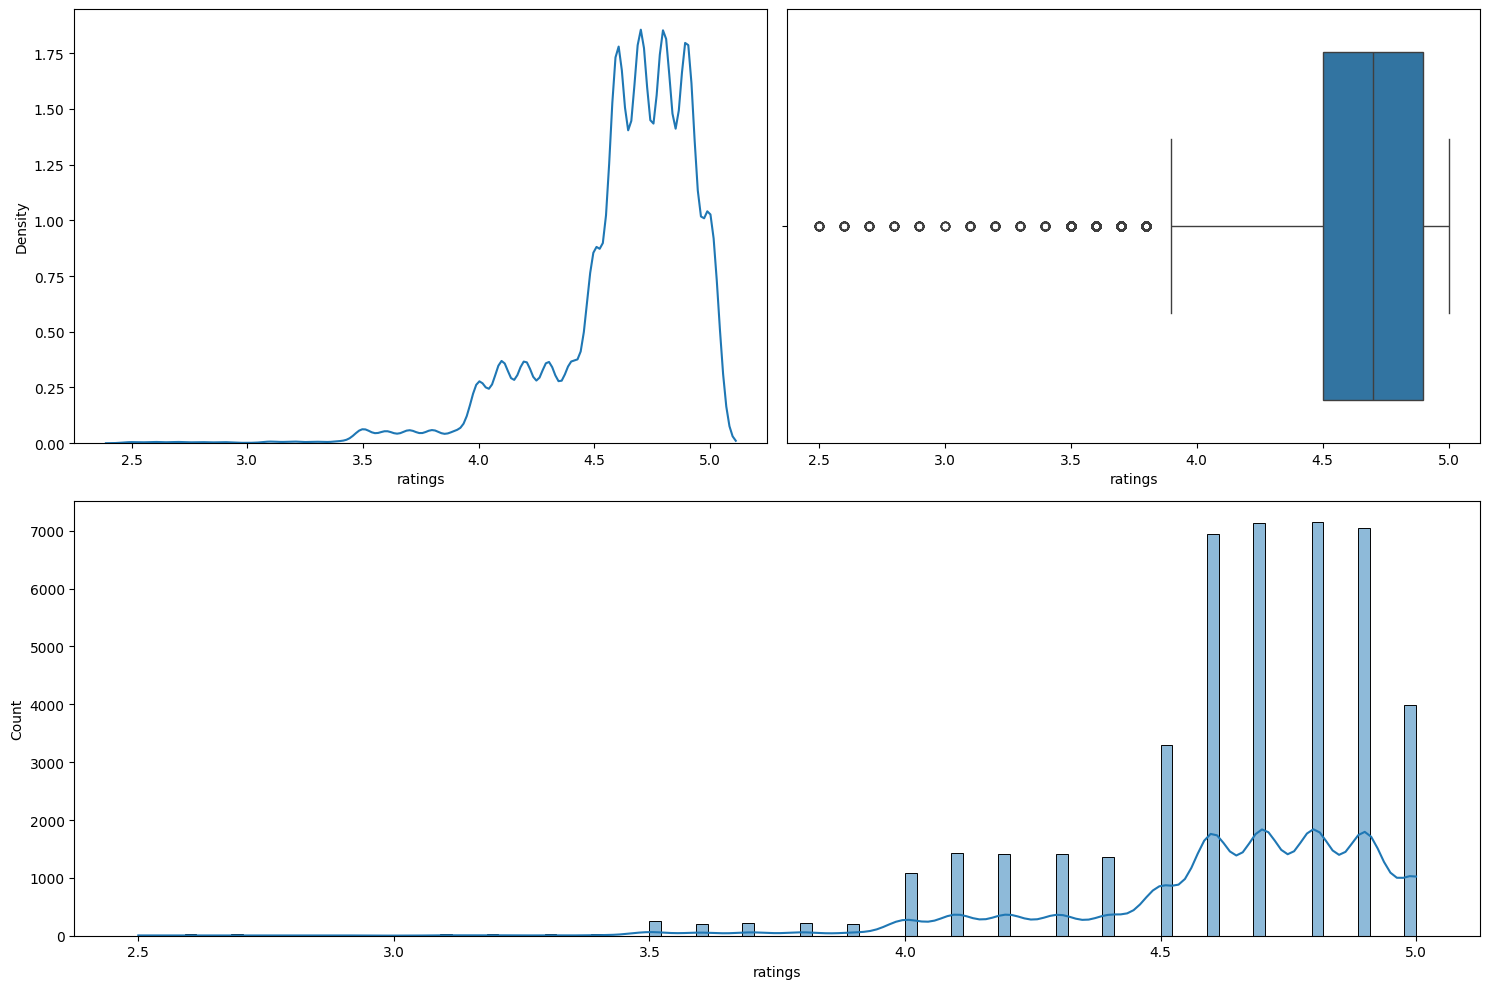

In [134]:
numerical_analysis(df_final, 'ratings', bins=5)

<Axes: xlabel='ratings', ylabel='time_taken'>

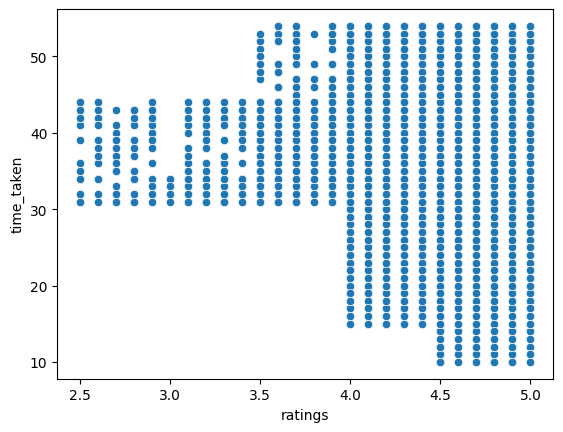

In [135]:
sns.scatterplot(df_final, x='ratings', y='time_taken')

- jinki rating jyada hai unnko deliveries bhi jyada mil rhi hai kyuki plot dense h wha 

<Figure size 1500x900 with 0 Axes>

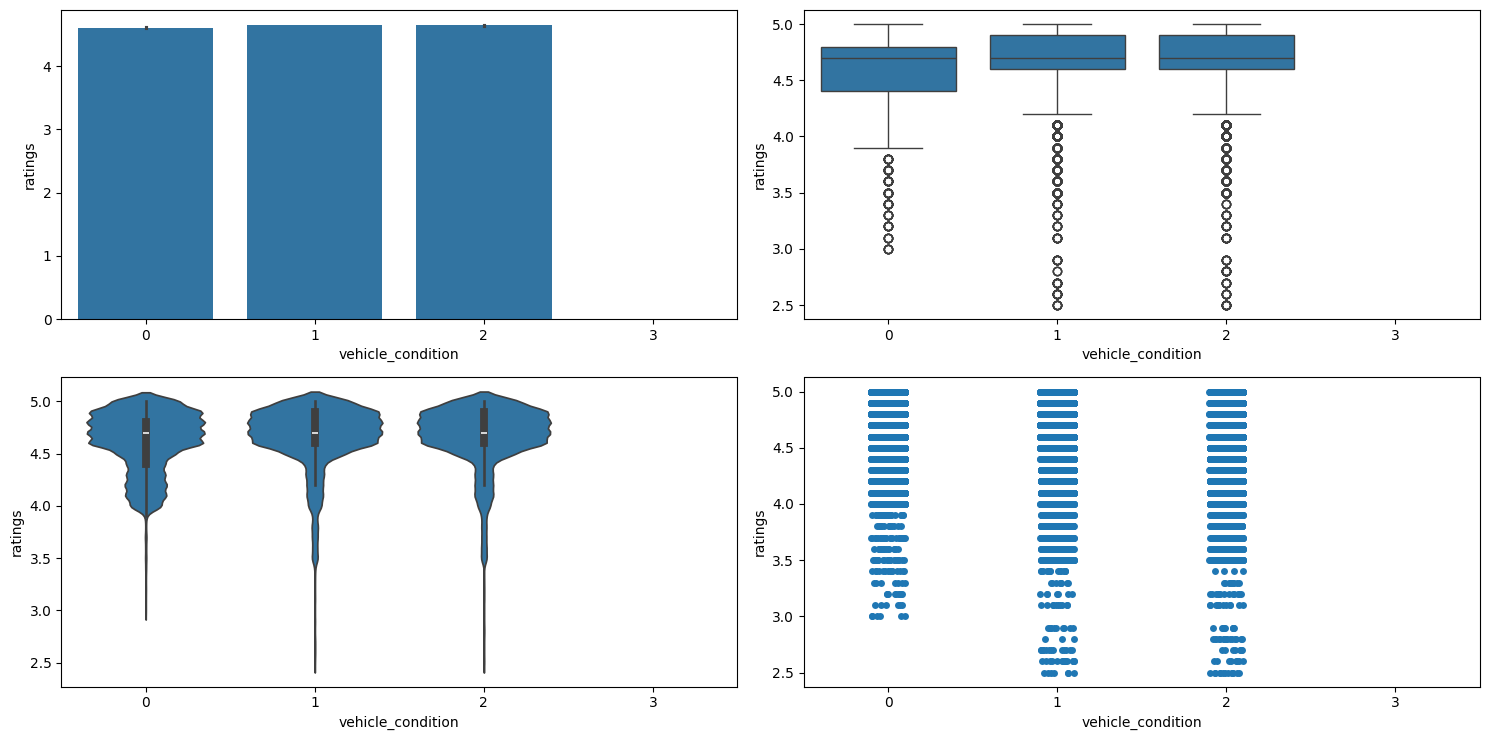

In [136]:
numerical_categorical_analysis(df_final, 'vehicle_condition', 'ratings')

- vehical jitna bekar hai (clsse to 3) hai ratings utni bekar hai 
- vehicle rating 3 me data hi nih means customer ne rate hi ni kiya jiki vehicle condition 3 tha 

In [137]:
(
    df_final[['ratings', 'vehicle_condition']]
    .loc[df_final['vehicle_condition'] == 3, 'ratings']
    .value_counts(dropna=False)
)

,count
ratings,
NaN,429


<Figure size 1500x900 with 0 Axes>

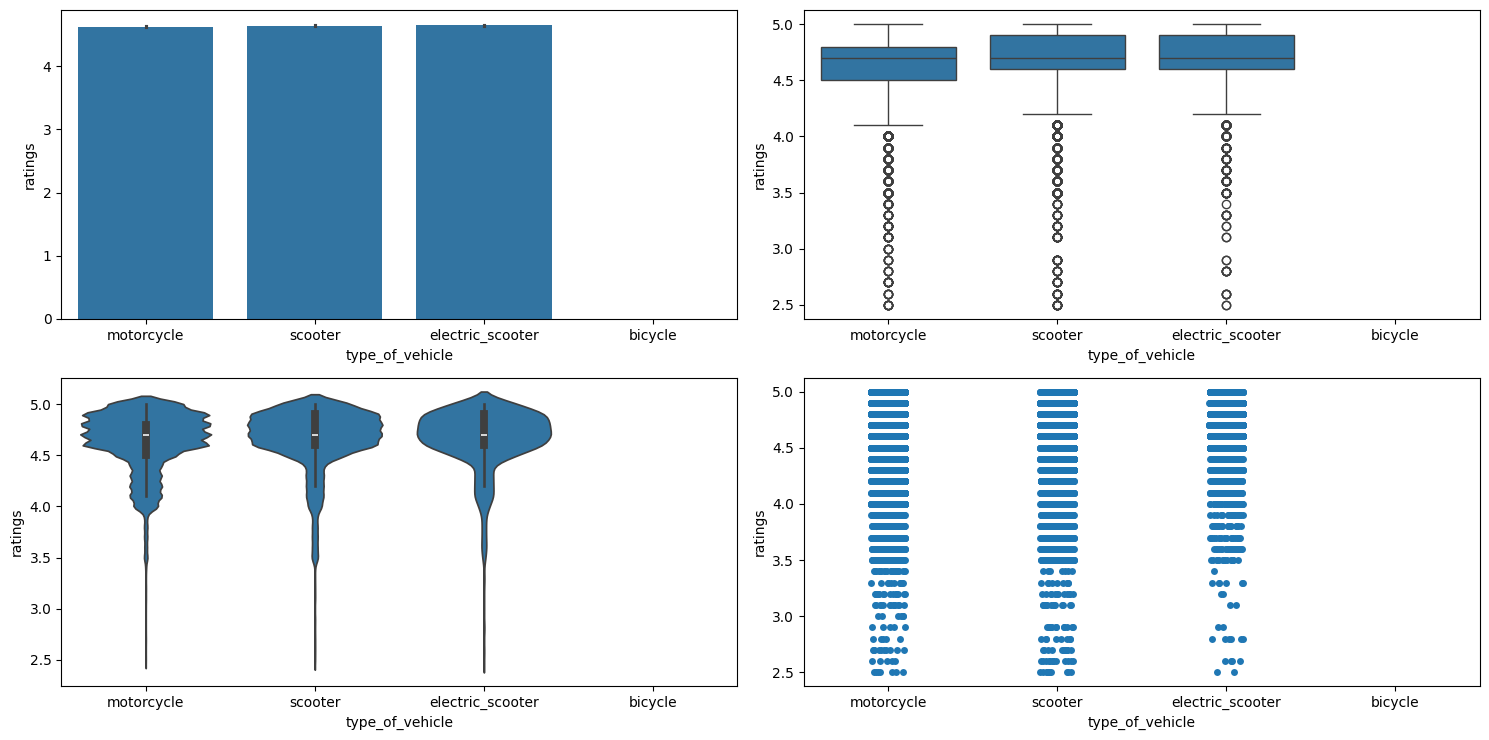

In [138]:
numerical_categorical_analysis(df_final, 'type_of_vehicle', 'ratings')

- electric scooters ko rating hgher mili hai  

<Figure size 1500x900 with 0 Axes>

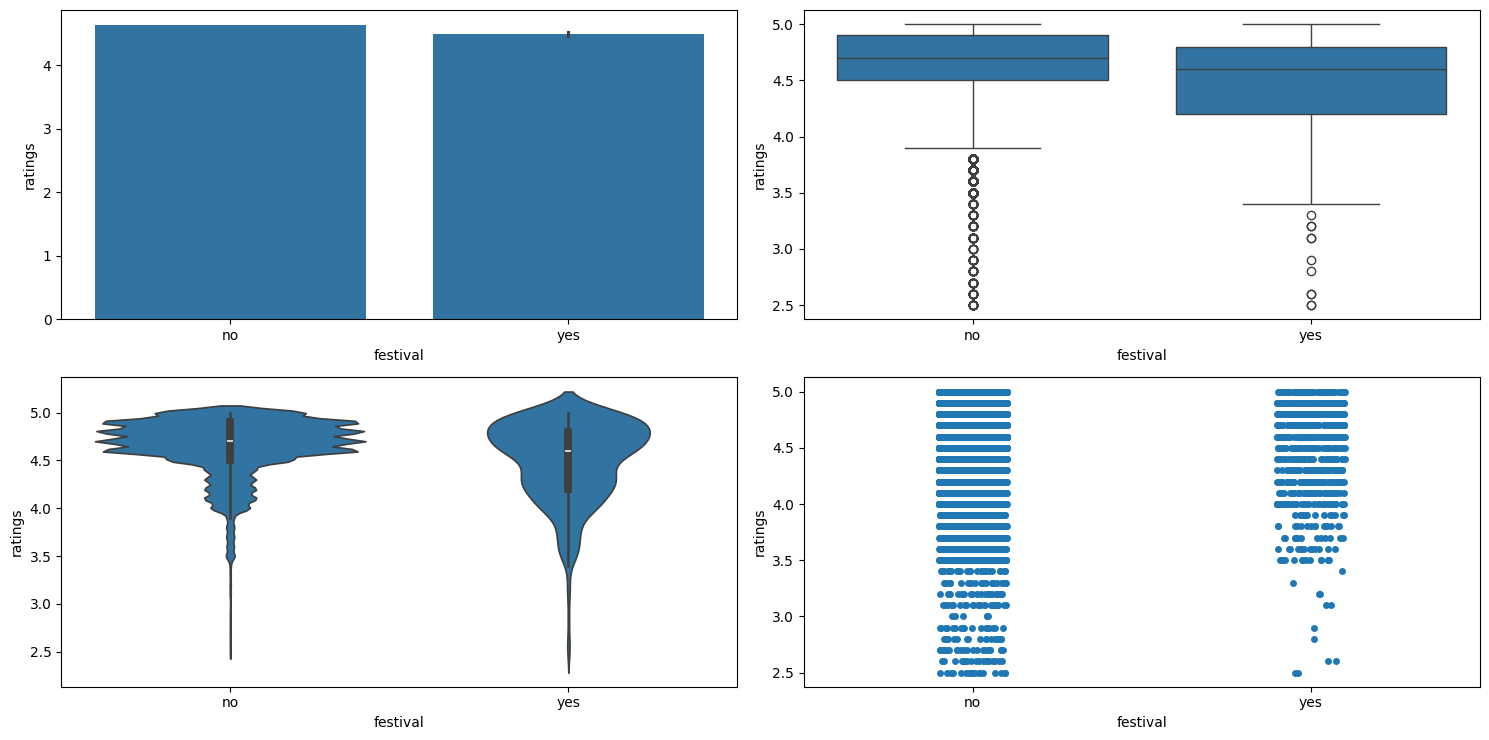

In [139]:
numerical_categorical_analysis(df_final, 'festival', 'ratings')

### location based columns 

In [140]:
df_final.columns[3: 7].tolist() + ['city_name']

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude',
 'city_name']

In [141]:
location_subset = df_final.loc[:, df_final.columns[3:7].tolist() + ['city_name']]
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45497,26.902328,75.794257,26.912328,75.804257,JAP
45498,NaN,NaN,NaN,NaN,AGR
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [142]:
location_subset.dtypes

,0
restaurant_latitude,float64
restaurant_longitude,float64
delivery_latitude,float64
delivery_longitude,float64
city_name,object


In [143]:
location_subset.dropna(inplace=True)
location_subset

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,city_name
0,22.745049,75.892471,22.765049,75.912471,INDO
1,12.913041,77.683237,13.043041,77.813237,BANG
2,12.914264,77.678400,12.924264,77.688400,BANG
3,11.003669,76.976494,11.053669,77.026494,COIMB
4,12.972793,80.249982,13.012793,80.289982,CHEN
...,...,...,...,...,...
45496,23.371292,85.327872,23.481292,85.437872,RANCHI
45497,26.902328,75.794257,26.912328,75.804257,JAP
45499,13.022394,80.242439,13.052394,80.272439,CHEN
45500,11.001753,76.986241,11.041753,77.026241,COIMB


In [144]:
# plot deliveries on map 
delivery_df = pd.DataFrame({
    'latitude': location_subset['delivery_latitude'],
    'longitude': location_subset['delivery_longitude'],
    'city_name': location_subset['city_name']
})

fig = px.scatter_mapbox(
    delivery_df,
    lat='latitude',
    lon='longitude',
    title='Delivery Points',
    hover_name='city_name'
)

fig.update_layout(
    mapbox_style='open-street-map',
    mapbox_center={
        'lat': 24.7,
        'lon': 77.41
    },
    mapbox_zoom=3
)

fig.show()

### order_date 

In [145]:
df_final.filter(like='order')

,order_date,type_of_order,order_day,order_month,order_day_of_week,order_time_hour,order_time_of_day
0,2022-03-19,snack,19,3,saturday,11.0,morning
1,2022-03-25,snack,25,3,friday,19.0,evening
2,2022-03-19,drinks,19,3,saturday,8.0,morning
3,2022-04-05,buffet,5,4,tuesday,18.0,evening
4,2022-03-26,snack,26,3,saturday,13.0,afternoon
...,...,...,...,...,...,...,...
45497,2022-03-24,meal,24,3,thursday,11.0,morning
45498,2022-02-16,buffet,16,2,wednesday,19.0,evening
45499,2022-03-11,drinks,11,3,friday,23.0,night
45500,2022-03-07,snack,7,3,monday,13.0,afternoon


In [146]:
order_date_subset = df_final.loc[:, ['order_date', 'order_day', 'order_month', 'order_day_of_week', 'is_weekend', 'festival']]
order_date_subset

,order_date,order_day,order_month,order_day_of_week,is_weekend,festival
0,2022-03-19,19,3,saturday,1,no
1,2022-03-25,25,3,friday,0,no
2,2022-03-19,19,3,saturday,1,no
3,2022-04-05,5,4,tuesday,0,no
4,2022-03-26,26,3,saturday,1,no
...,...,...,...,...,...,...
45497,2022-03-24,24,3,thursday,0,no
45498,2022-02-16,16,2,wednesday,0,no
45499,2022-03-11,11,3,friday,0,no
45500,2022-03-07,7,3,monday,0,no


<Figure size 1500x900 with 0 Axes>

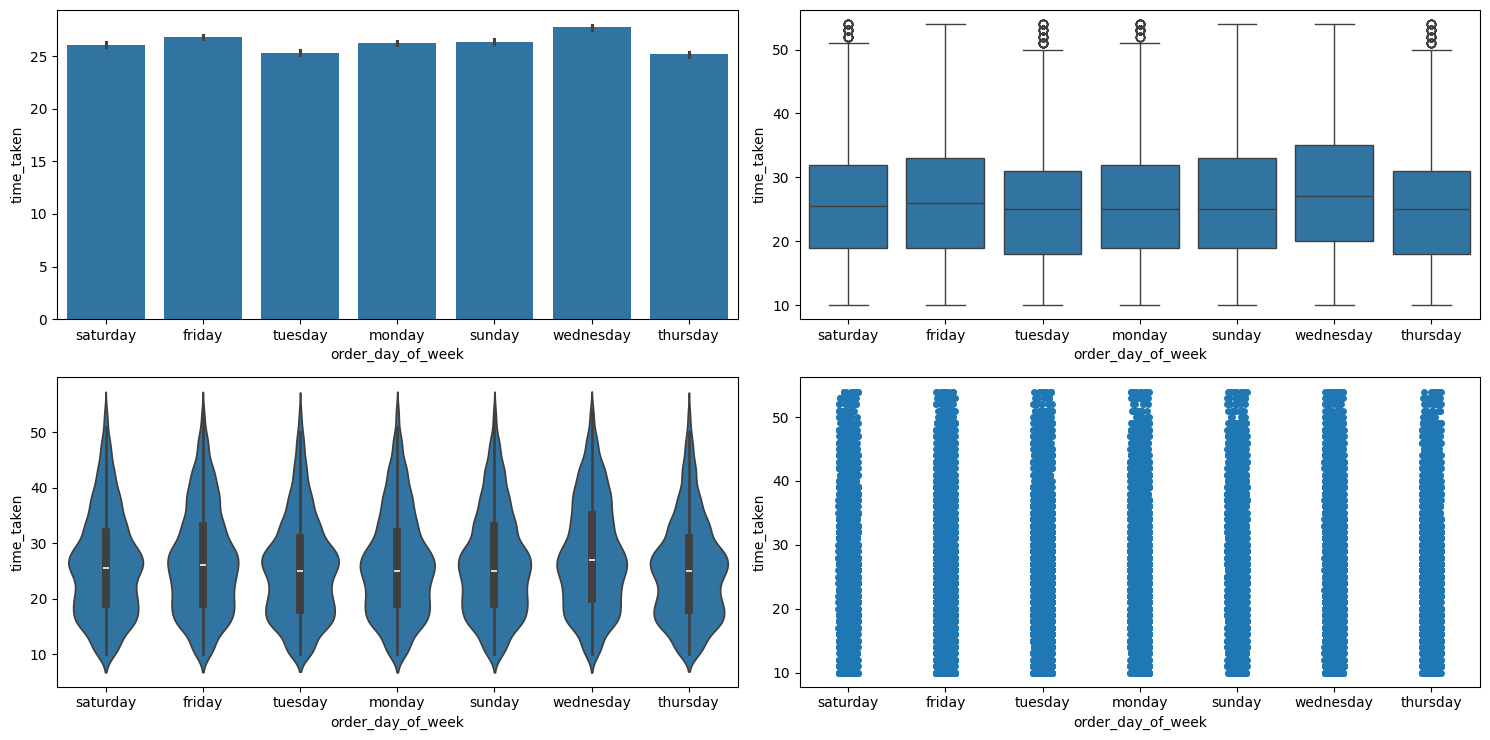

In [147]:
numerical_categorical_analysis(df_final, 'order_day_of_week', 'time_taken')

<Figure size 1500x900 with 0 Axes>

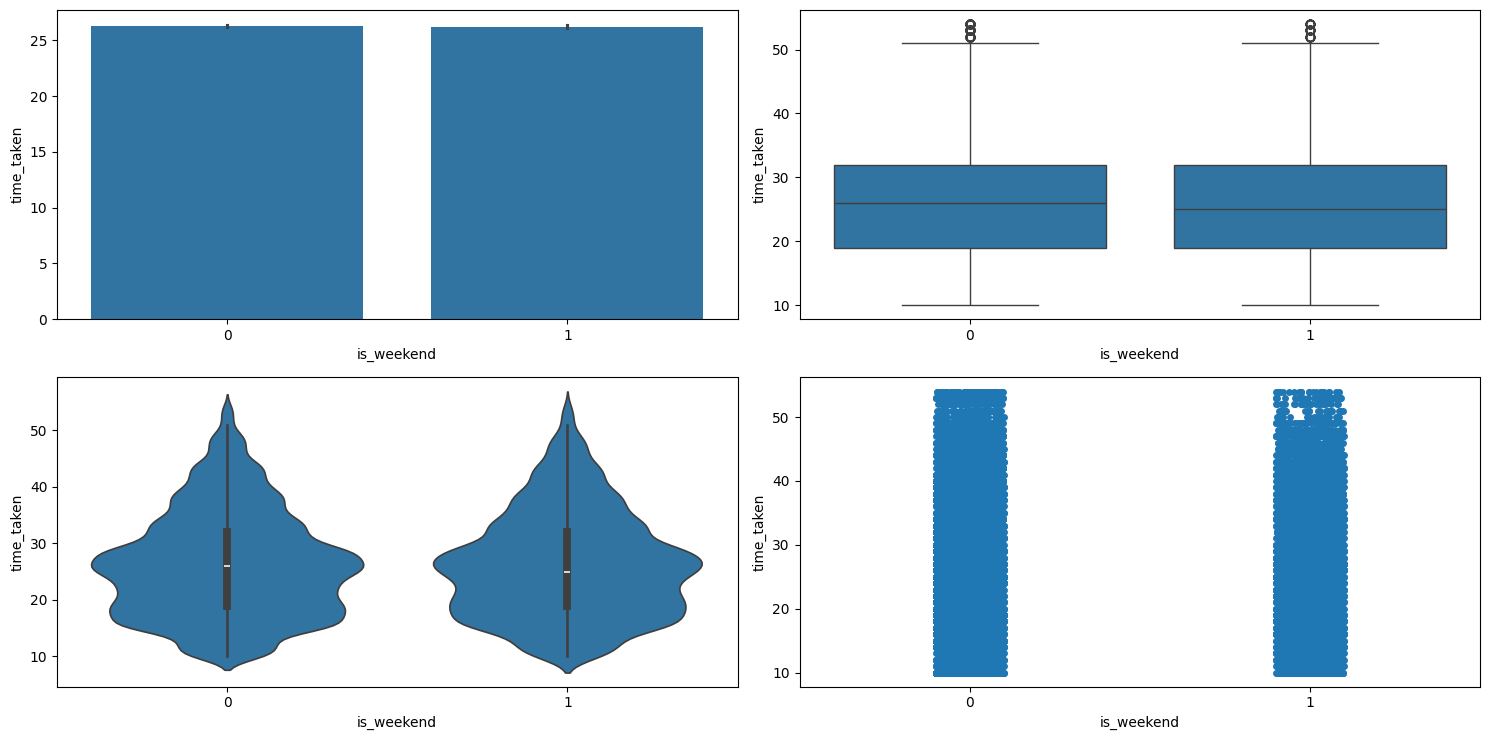

In [148]:
numerical_categorical_analysis(df_final, 'is_weekend', 'time_taken')

In [149]:
chi_2_test(df_final, 'is_weekend', 'traffic')

0.6845961396354259
fail to reject the null hypothesis. there is no significant assosiation betweem is_weekend and traffic


<Figure size 1500x900 with 0 Axes>

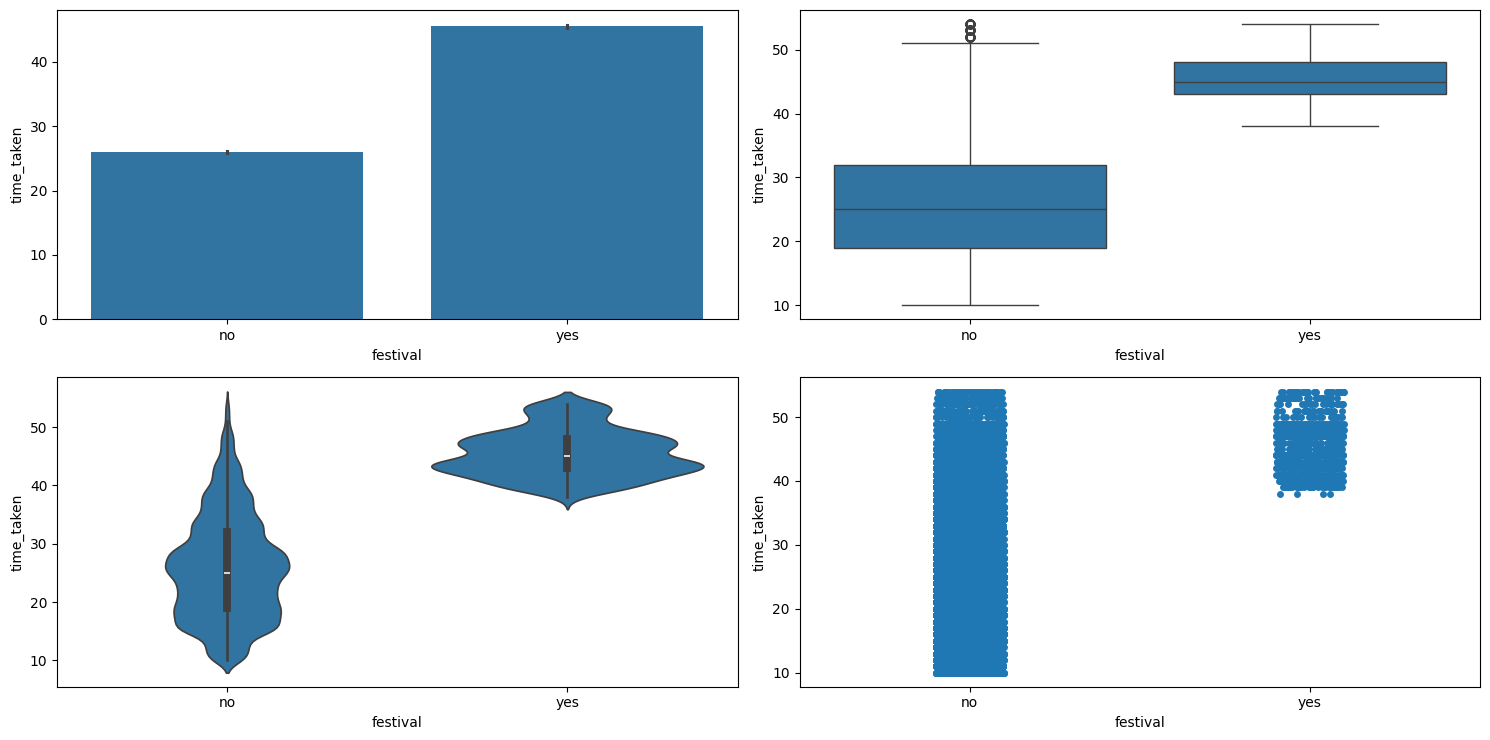

In [150]:
numerical_categorical_analysis(df_final, 'festival', 'time_taken')

- festival ke time delivery me time jyada lgta hai 

In [151]:
chi_2_test(df_final, 'festival', 'traffic')

1.1223471129146869e-153
reject the null hypothesis. there is a significant assosiation betweem festival and traffic


- han krte hai 

In [152]:
df_final.pivot_table(index='traffic', columns='festival', values='time_taken', aggfunc='mean')

festival,no,yes
traffic,,
high,27.010373,45.826087
jam,30.538039,46.093651
low,21.284332,42.020000
medium,26.550288,43.715385


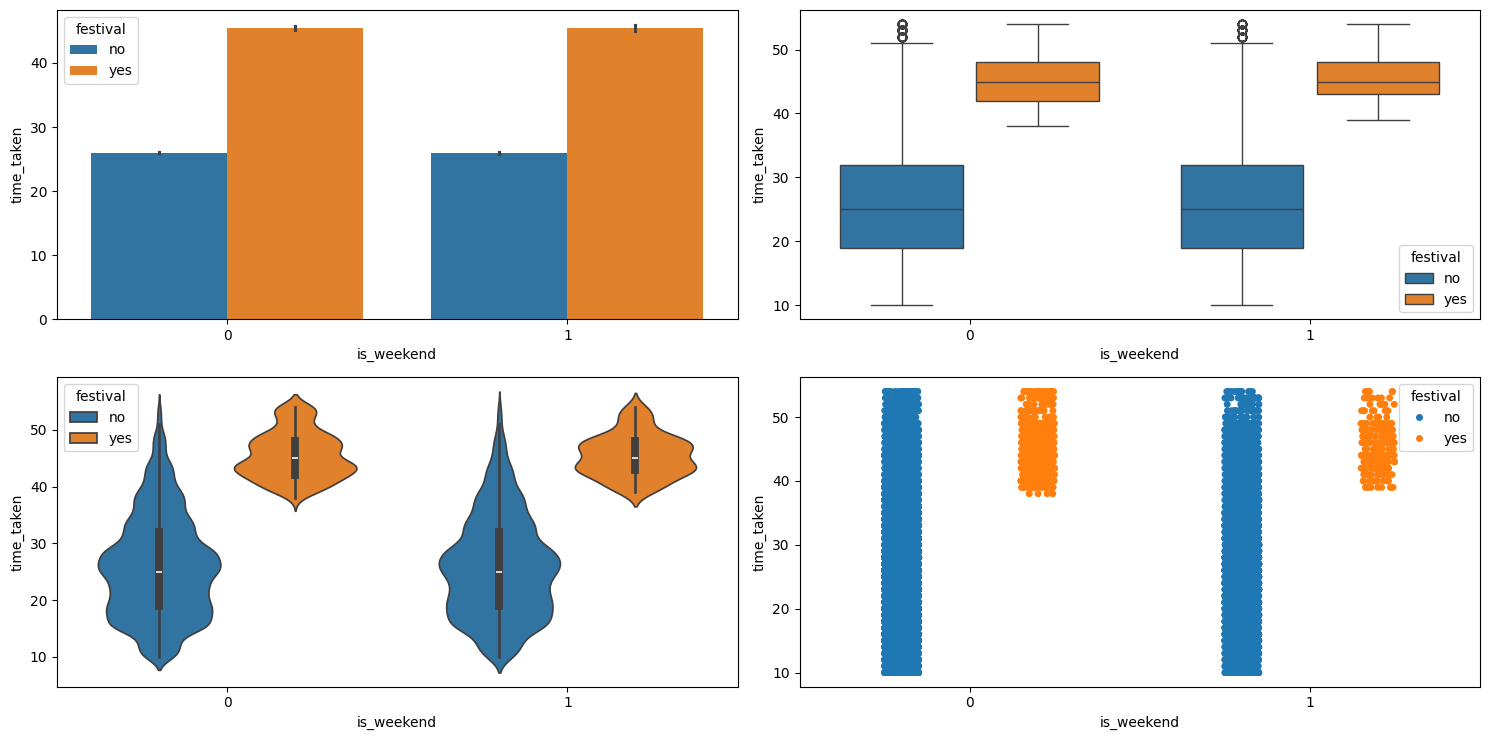

In [153]:
multivariate_analysis(df_final, 'time_taken', 'is_weekend', 'festival')

### order time 

In [154]:
time_subset = df_final.loc[:, ['order_time_hour', 'order_time_of_day', 'pickup_time_minutes']]
time_subset

,order_time_hour,order_time_of_day,pickup_time_minutes
0,11.0,morning,15.0
1,19.0,evening,5.0
2,8.0,morning,15.0
3,18.0,evening,10.0
4,13.0,afternoon,15.0
...,...,...,...
45497,11.0,morning,10.0
45498,19.0,evening,15.0
45499,23.0,night,15.0
45500,13.0,afternoon,5.0


<Figure size 1500x900 with 0 Axes>

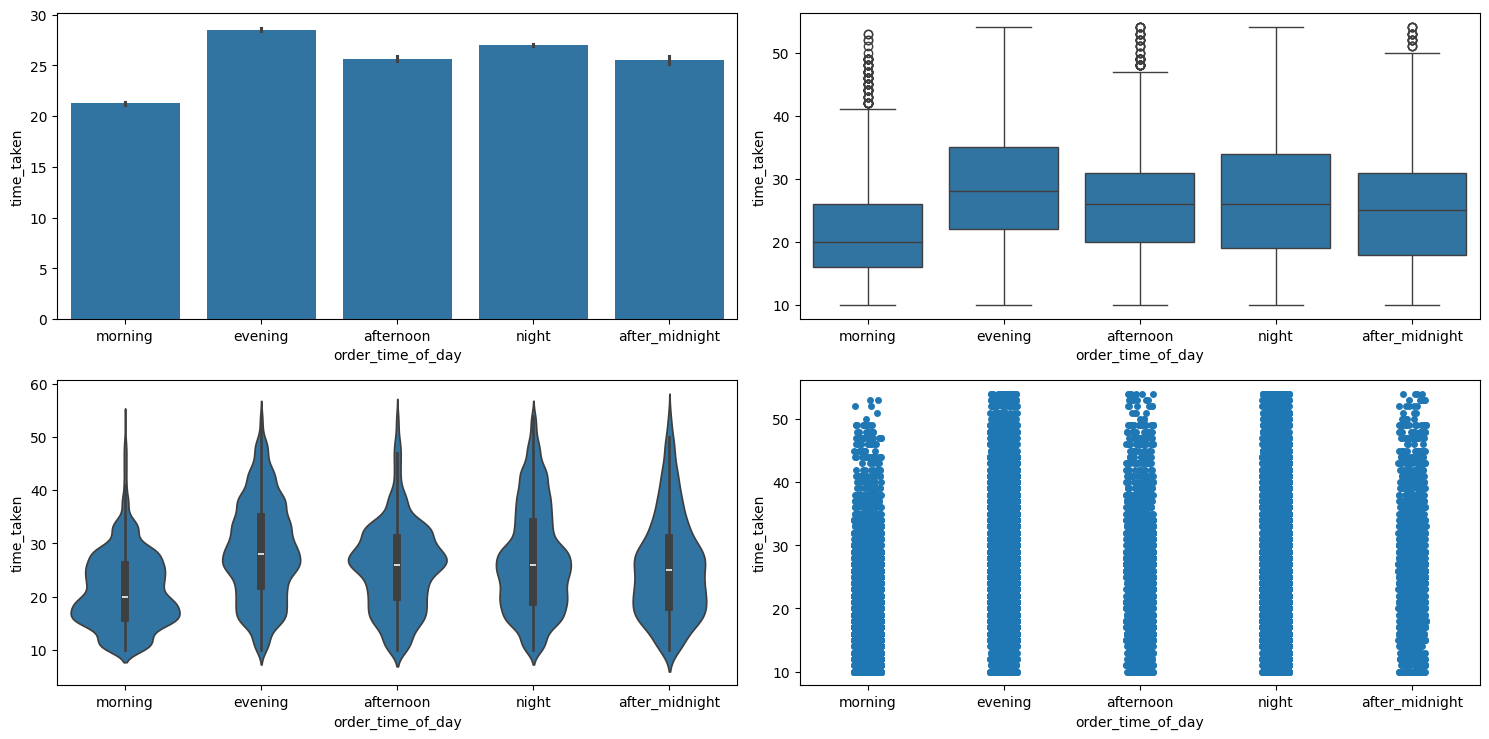

In [155]:
numerical_categorical_analysis(df_final, 'order_time_of_day', 'time_taken')

In [156]:
anova_test(df_final, 'time_taken', 'order_time_of_day')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and order_time_of_day


In [157]:
df_final['order_time_hour'].value_counts().head()

,count
order_time_hour,
21.0,4686
19.0,4595
22.0,4576
20.0,4539
23.0,4511


,count,percentage
order_time_hour,,
21.0,4686,10.68%
19.0,4595,10.48%
22.0,4576,10.43%
20.0,4539,10.35%
23.0,4511,10.28%
18.0,4480,10.21%
17.0,4278,9.75%
10.0,1991,4.54%
11.0,1962,4.47%


**************************************************
the unique categories in order_time_hour columns are [11.0, 19.0, 8.0, 18.0, 13.0, 21.0, 17.0, 20.0, 14.0, 9.0, 22.0, 12.0, 23.0, nan, 10.0, 16.0, 15.0, 0.0]
**************************************************
the number of categories in order_time_hour columns are 17


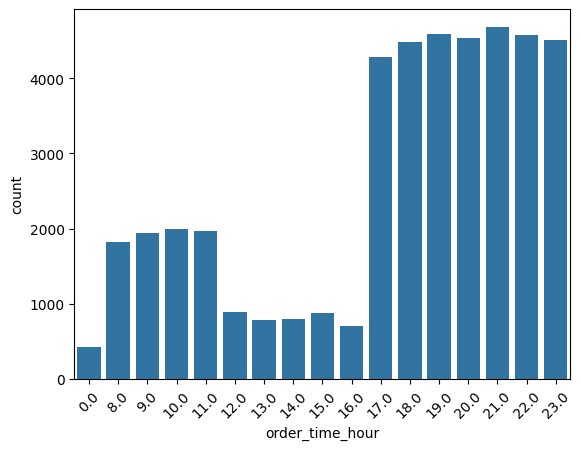

In [158]:
categorical_analysis(df_final, 'order_time_hour')

,count,percentage
order_time_of_day,,
night,18312,40.24%
evening,13353,29.35%
morning,7718,16.96%
afternoon,4049,8.9%
after_midnight,2070,4.55%


**************************************************
the unique categories in order_time_of_day columns are ['morning', 'evening', 'afternoon', 'night', 'after_midnight']
**************************************************
the number of categories in order_time_of_day columns are 5


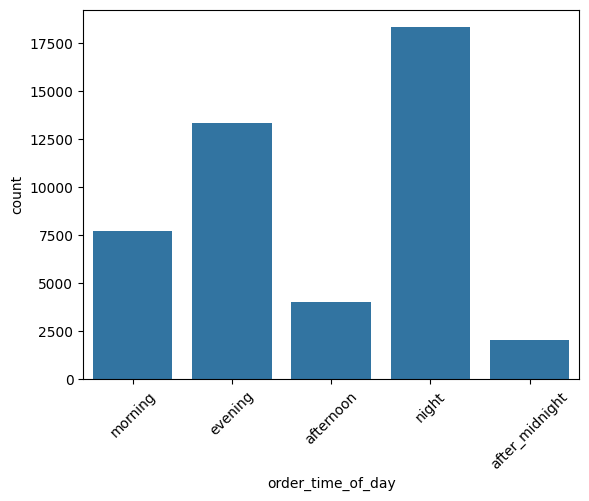

In [159]:
categorical_analysis(df_final, 'order_time_of_day')

### pickup_time

In [160]:
df_final['pickup_time_minutes'].dtype

dtype('float64')

<Axes: xlabel='pickup_time_minutes', ylabel='time_taken'>

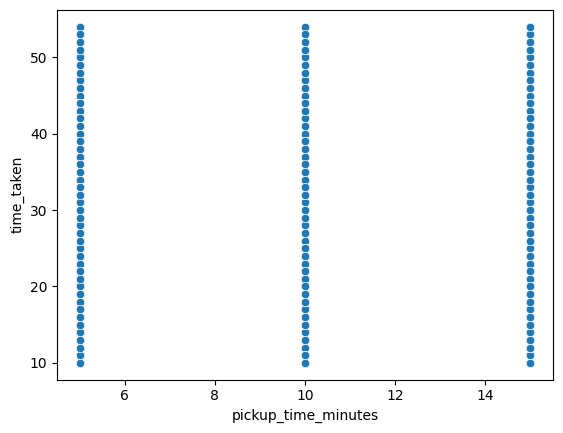

In [161]:
sns.scatterplot(df_final, x='pickup_time_minutes', y='time_taken')

- pickup time me 3 hi categories hai 5min , 10min, 15min
- isko ordinal encode kr skte hai 

,count,percentage
pickup_time_minutes,,
5.0,14703,33.52%
15.0,14610,33.31%
10.0,14549,33.17%


**************************************************
the unique categories in pickup_time_minutes columns are [15.0, 5.0, 10.0, nan]
**************************************************
the number of categories in pickup_time_minutes columns are 3


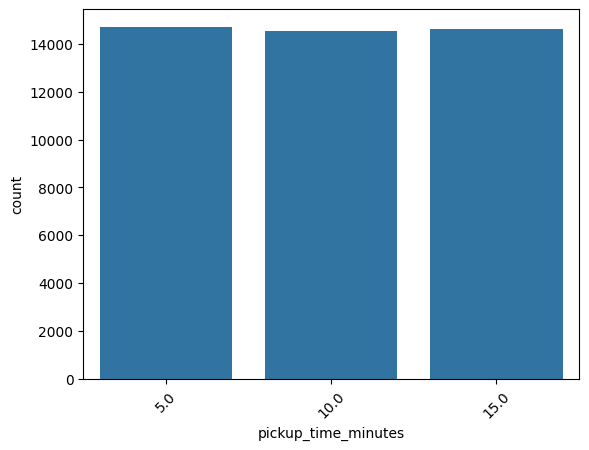

In [162]:
categorical_analysis(df_final, 'pickup_time_minutes')

<Figure size 1500x900 with 0 Axes>

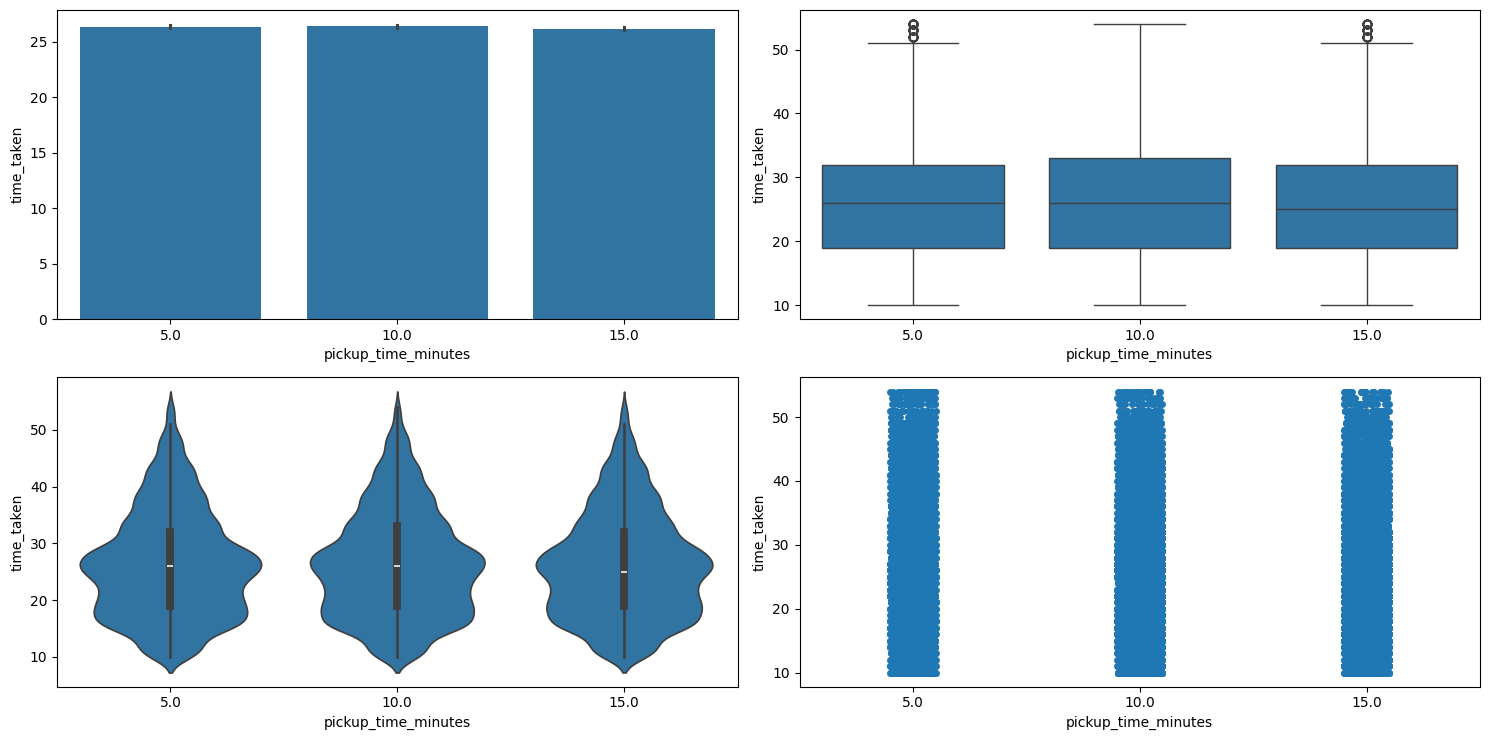

In [163]:
numerical_categorical_analysis(df_final, 'pickup_time_minutes', 'time_taken')

In [164]:
anova_test(df_final, 'time_taken', 'pickup_time_minutes')

0.09932647028954891
fail to reject the null hypothesis. there is no significant assosiation betweem time_taken and pickup_time_minutes


### Traffic

In [165]:
df_final['traffic'].dtype

dtype('O')

,count,percentage
traffic,,
low,15477,34.4%
jam,14143,31.43%
medium,10947,24.33%
high,4425,9.84%


**************************************************
the unique categories in traffic columns are ['high', 'jam', 'low', 'medium', nan]
**************************************************
the number of categories in traffic columns are 4


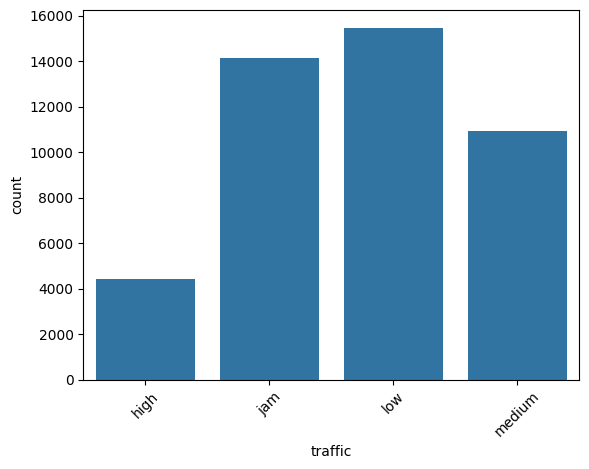

In [166]:
categorical_analysis(df_final, 'traffic')

In [167]:
chi_2_test(df_final, 'city_type', 'traffic')

2.3390790568495405e-104
reject the null hypothesis. there is a significant assosiation betweem city_type and traffic


In [168]:
chi_2_test(df_final, 'city_name', 'traffic')

0.49780801809552505
fail to reject the null hypothesis. there is no significant assosiation betweem city_name and traffic


<Figure size 1500x900 with 0 Axes>

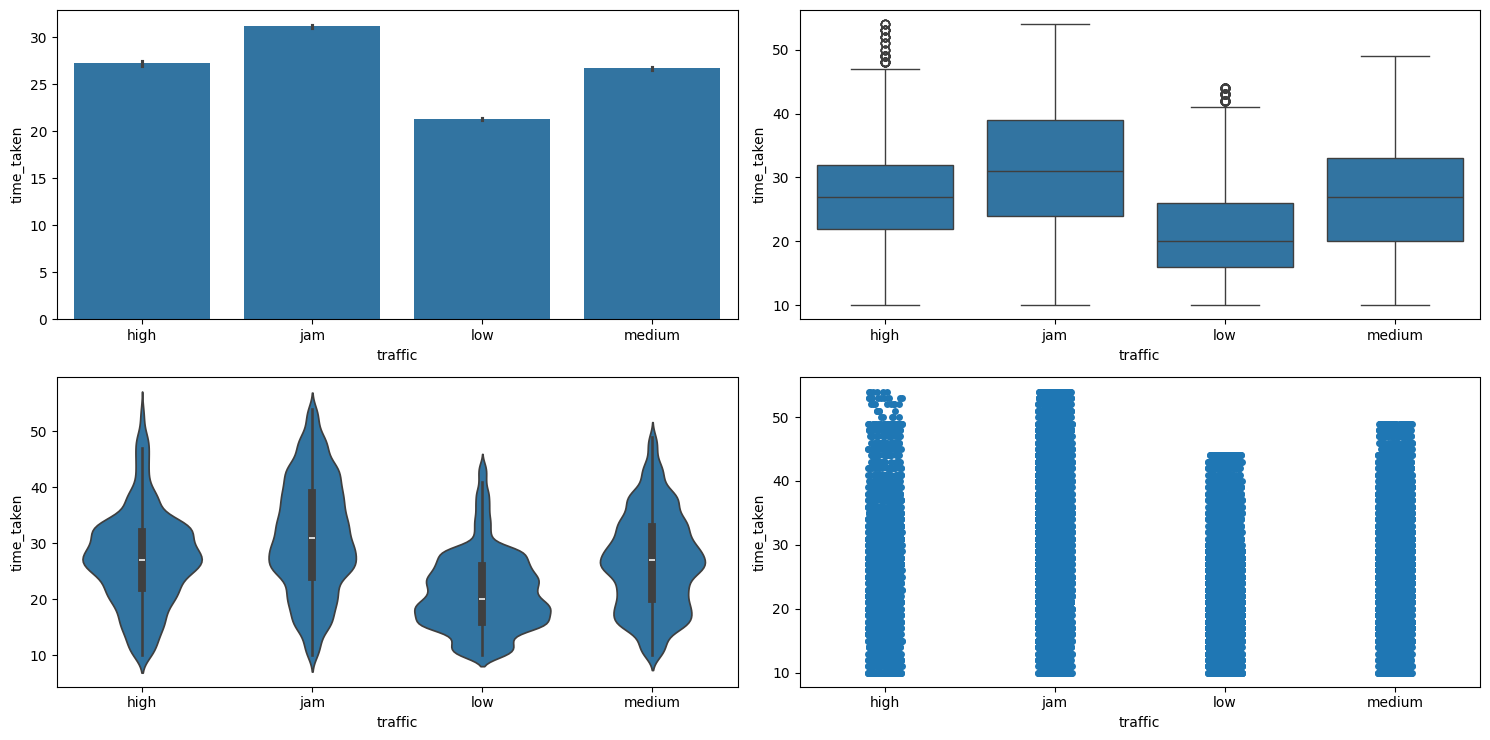

In [169]:
numerical_categorical_analysis(df_final, 'traffic', 'time_taken')

In [170]:
anova_test(df_final, 'time_taken', 'traffic')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and traffic


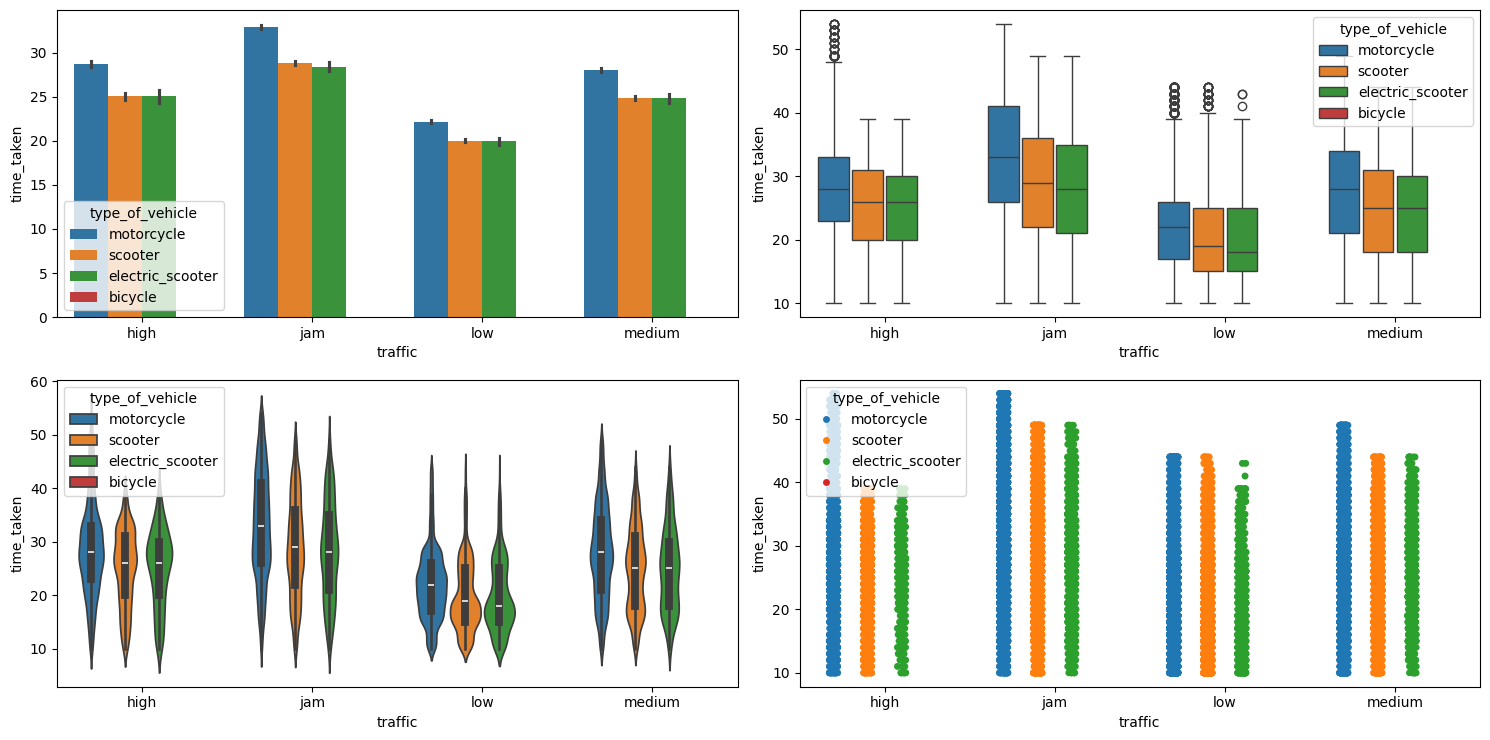

In [171]:
multivariate_analysis(df_final, 'time_taken', 'traffic', 'type_of_vehicle')

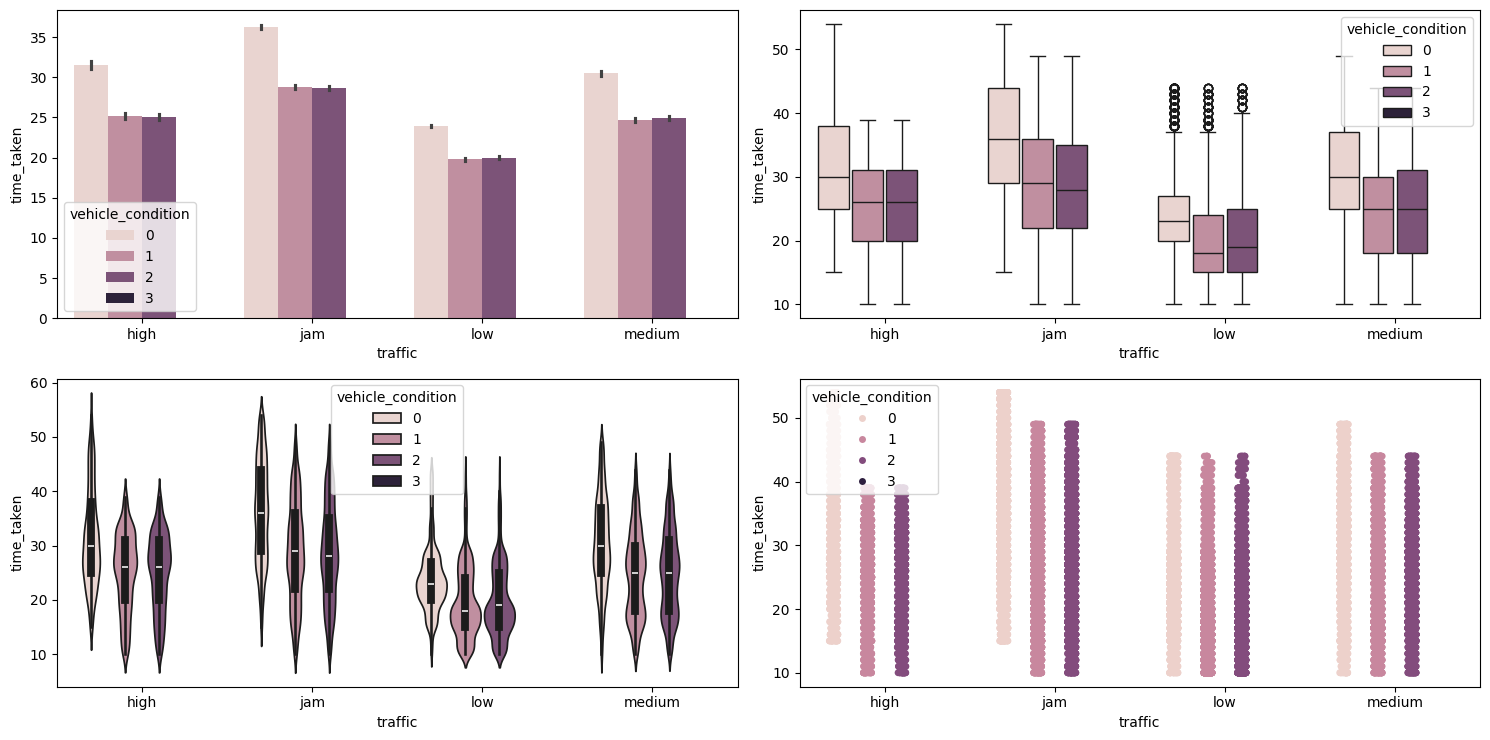

In [173]:
multivariate_analysis(df_final, 'time_taken', 'traffic', 'vehicle_condition')

- iska interpretation hai ki good vehical condition ko long distance wali dilivery mili h isliye tme jyada lga 


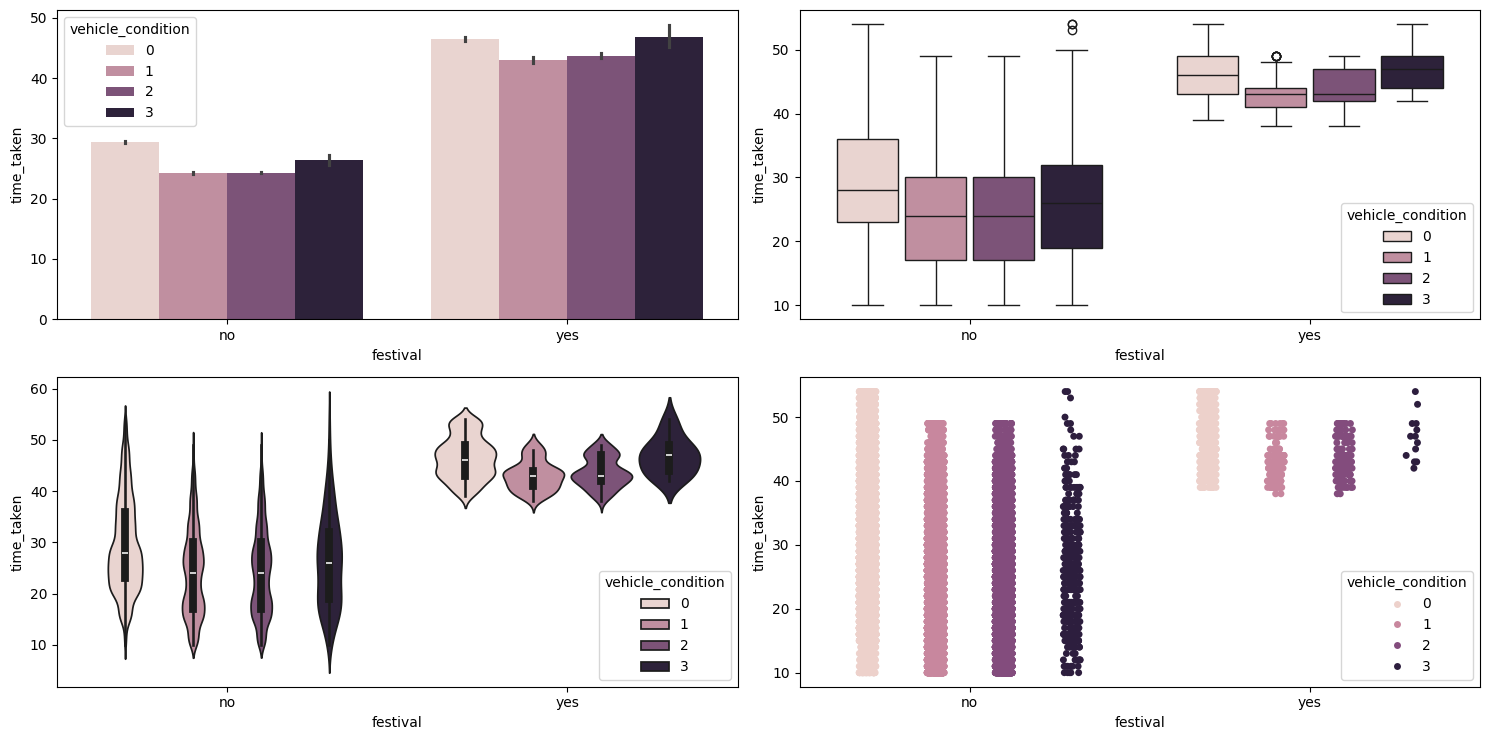

In [174]:
multivariate_analysis(df_final, 'time_taken', 'festival', 'vehicle_condition')

<Figure size 1500x900 with 0 Axes>

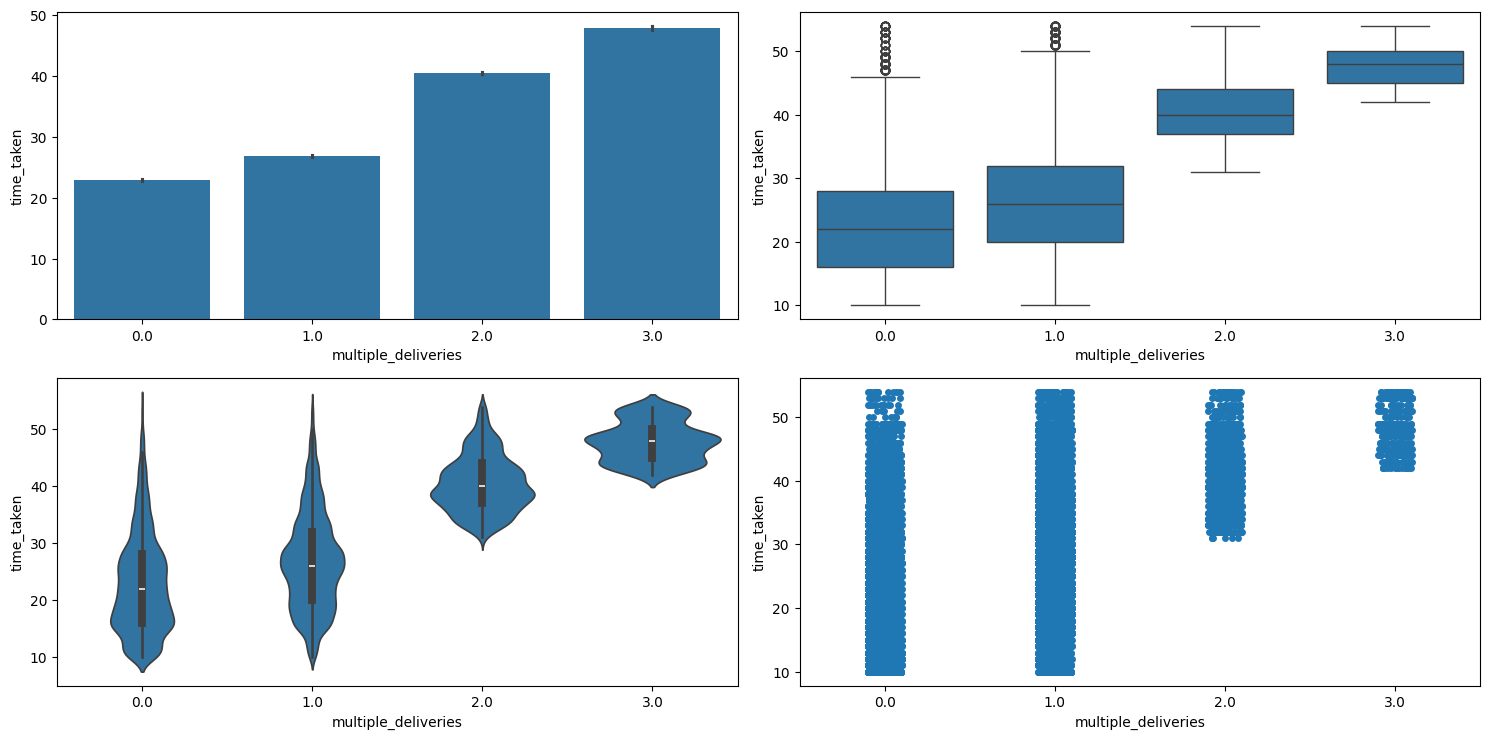

In [175]:
numerical_categorical_analysis(df_final, 'multiple_deliveries', 'time_taken')

In [176]:
anova_test(df_final, 'time_taken', 'multiple_deliveries')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and multiple_deliveries


<Figure size 1500x900 with 0 Axes>

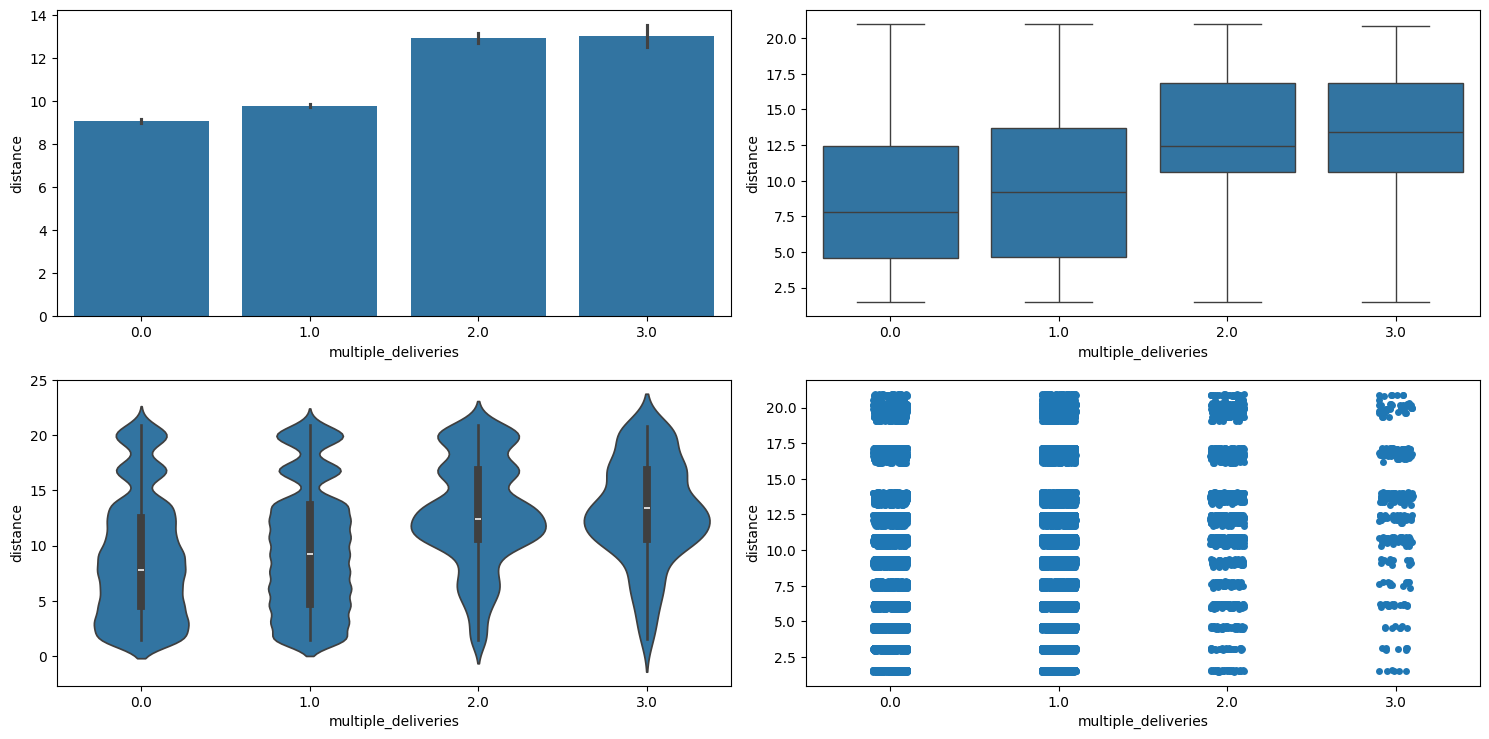

In [177]:
numerical_categorical_analysis(df_final, 'multiple_deliveries', 'distance')

### weather 

In [178]:
df_final['weather'].dtype

dtype('O')

,count,percentage
weather,,
fog,7654,17.02%
stormy,7586,16.87%
cloudy,7536,16.76%
sandstorms,7495,16.66%
windy,7422,16.5%
sunny,7284,16.19%


**************************************************
the unique categories in weather columns are ['sunny', 'stormy', 'sandstorms', 'cloudy', 'fog', 'windy', nan]
**************************************************
the number of categories in weather columns are 6


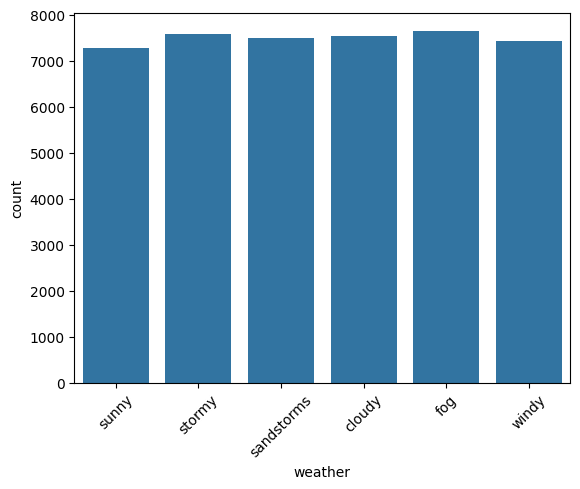

In [179]:
categorical_analysis(df_final, 'weather')

<Figure size 1500x900 with 0 Axes>

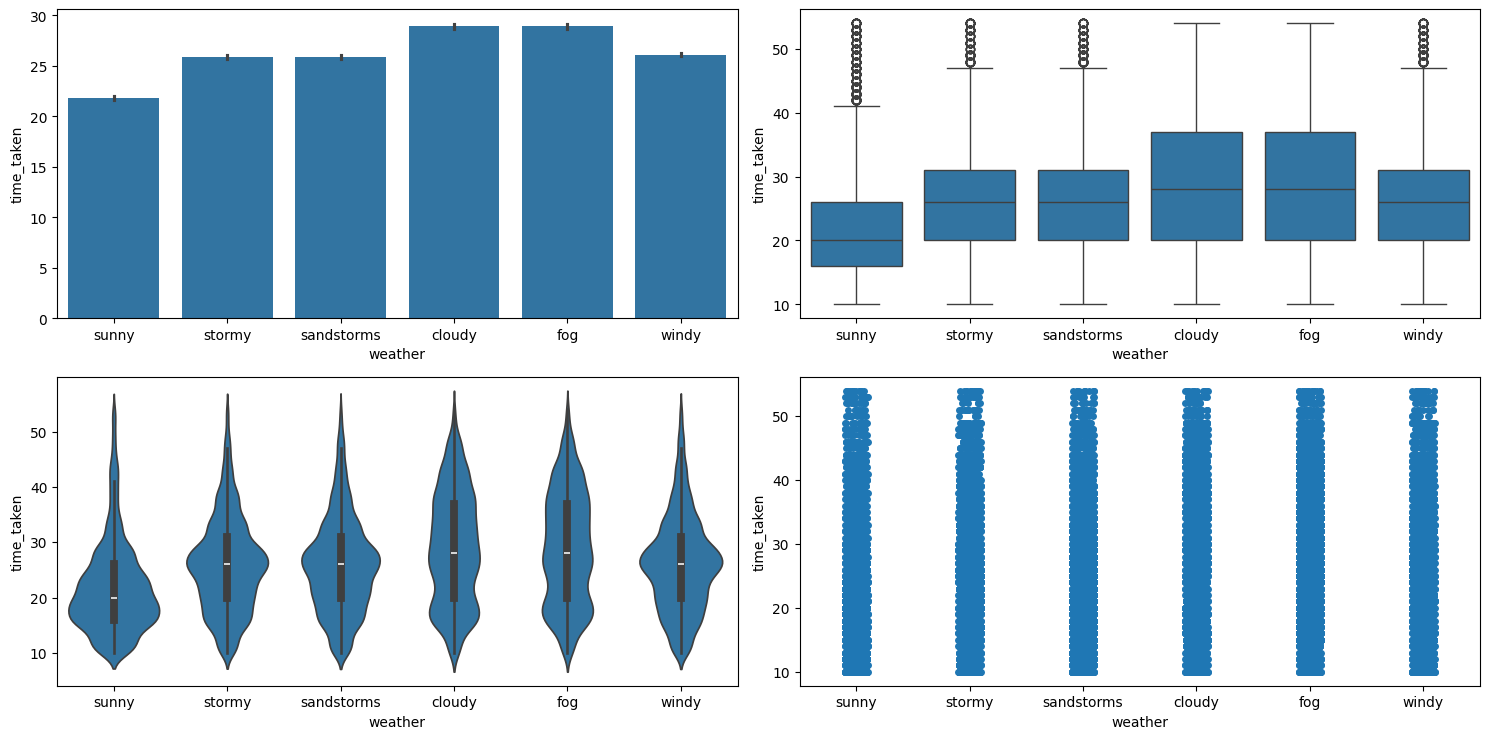

In [180]:
numerical_categorical_analysis(df_final, 'weather', 'time_taken')

In [181]:
anova_test(df_final, 'time_taken', 'weather')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and weather


In [183]:
chi_2_test(df_final, 'weather', 'traffic')

0.4796388074753828
fail to reject the null hypothesis. there is no significant assosiation betweem weather and traffic


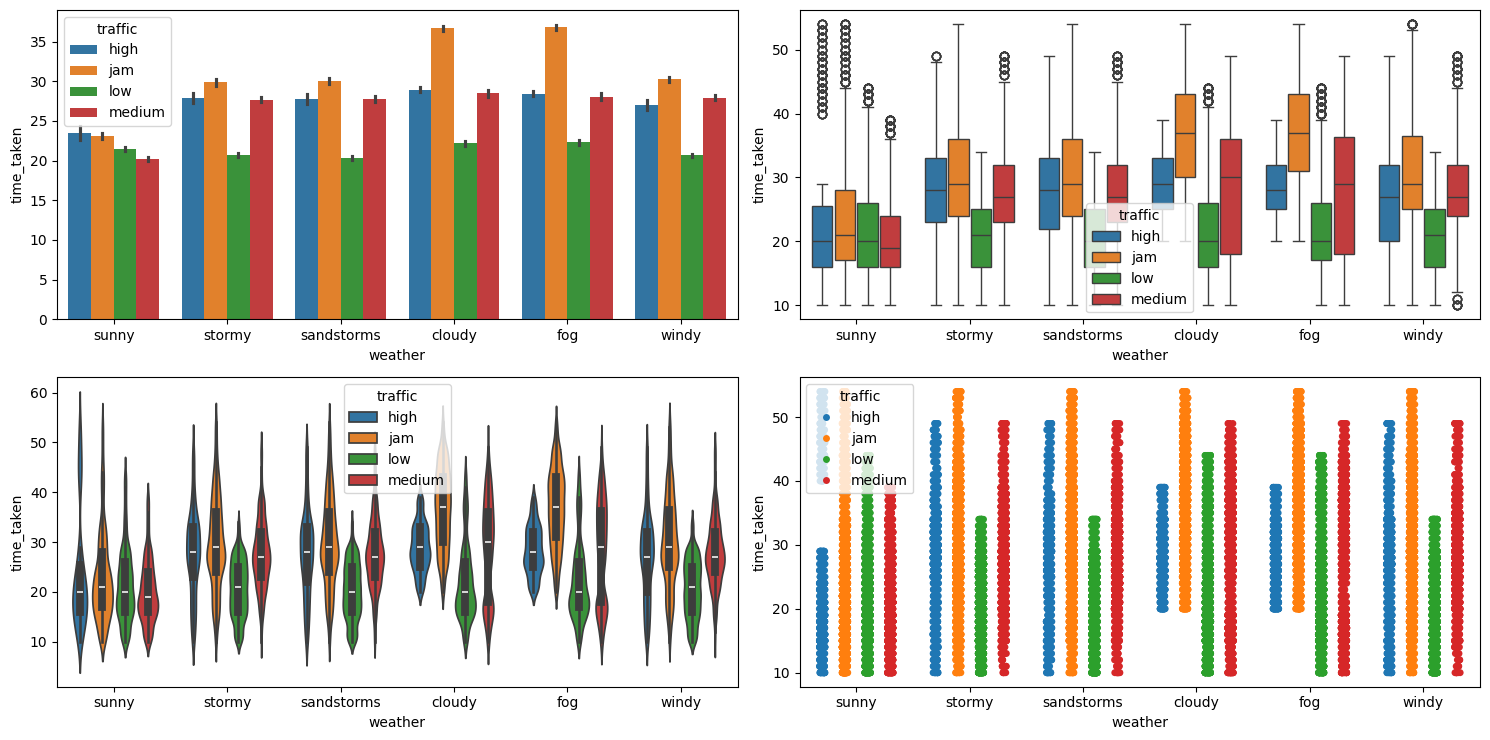

In [187]:
multivariate_analysis(df_final, 'time_taken', 'weather', 'traffic')

In [188]:
df_final.pivot_table(index='weather', columns='traffic', values='time_taken', aggfunc='mean')

traffic,high,jam,low,medium
weather,,,,
cloudy,28.940860,36.689655,22.208445,28.483134
fog,28.426546,36.806916,22.303427,28.044816
sandstorms,27.711840,30.018758,20.297049,27.738522
stormy,27.845839,29.850194,20.681734,27.680502
sunny,23.448980,23.082132,21.449293,20.195518
windy,26.972789,30.219056,20.665862,27.888769


### vehical condition and type

,count,percentage
vehicle_condition,,
2,15034,33.04%
1,15030,33.03%
0,15009,32.99%
3,429,0.94%


**************************************************
the unique categories in vehicle_condition columns are [2, 0, 1, 3]
**************************************************
the number of categories in vehicle_condition columns are 4


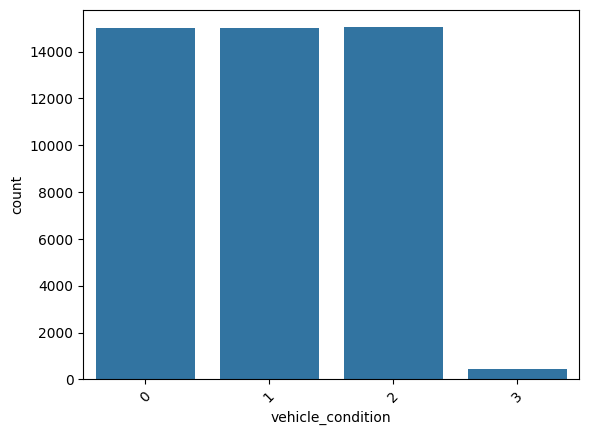

In [189]:
categorical_analysis(df_final, 'vehicle_condition')

<Figure size 1500x900 with 0 Axes>

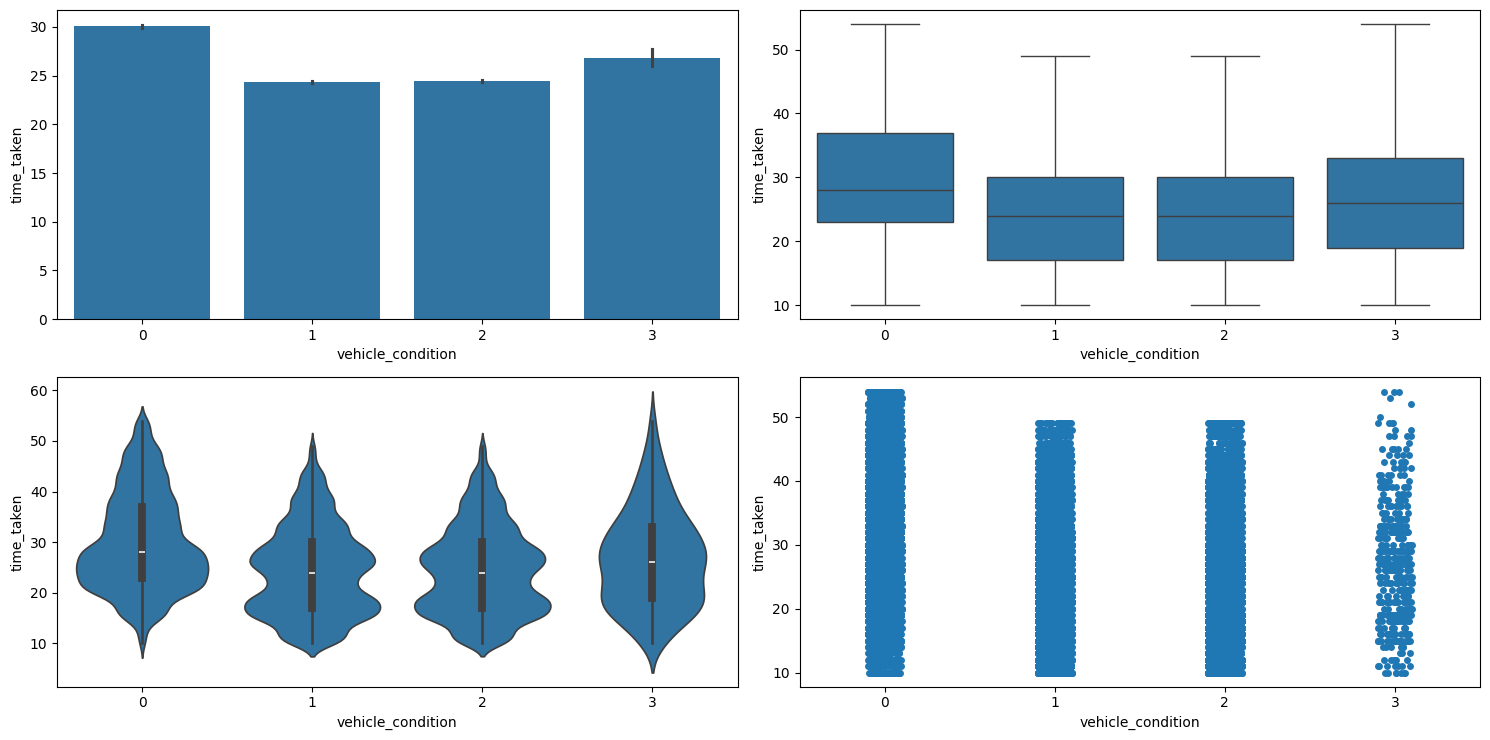

In [191]:
numerical_categorical_analysis(df_final, 'vehicle_condition', 'time_taken')

In [192]:
anova_test(df_final, 'time_taken', 'vehicle_condition')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and vehicle_condition


,count,percentage
type_of_vehicle,,
motorcycle,26427,58.08%
scooter,15244,33.5%
electric_scooter,3778,8.3%
bicycle,53,0.12%


**************************************************
the unique categories in type_of_vehicle columns are ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
**************************************************
the number of categories in type_of_vehicle columns are 4


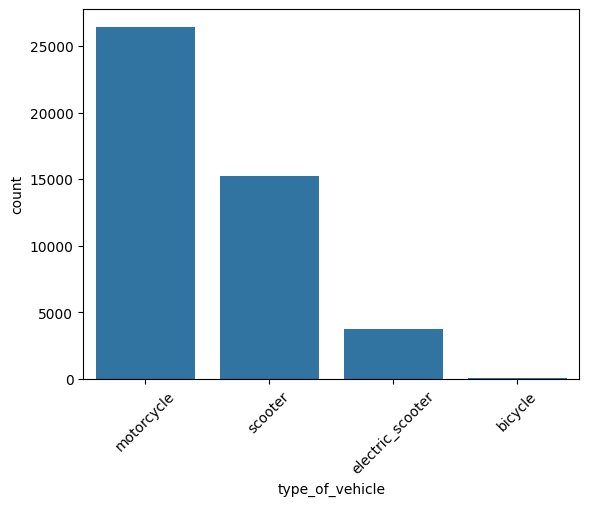

In [193]:
categorical_analysis(df_final, 'type_of_vehicle')

<Figure size 1500x900 with 0 Axes>

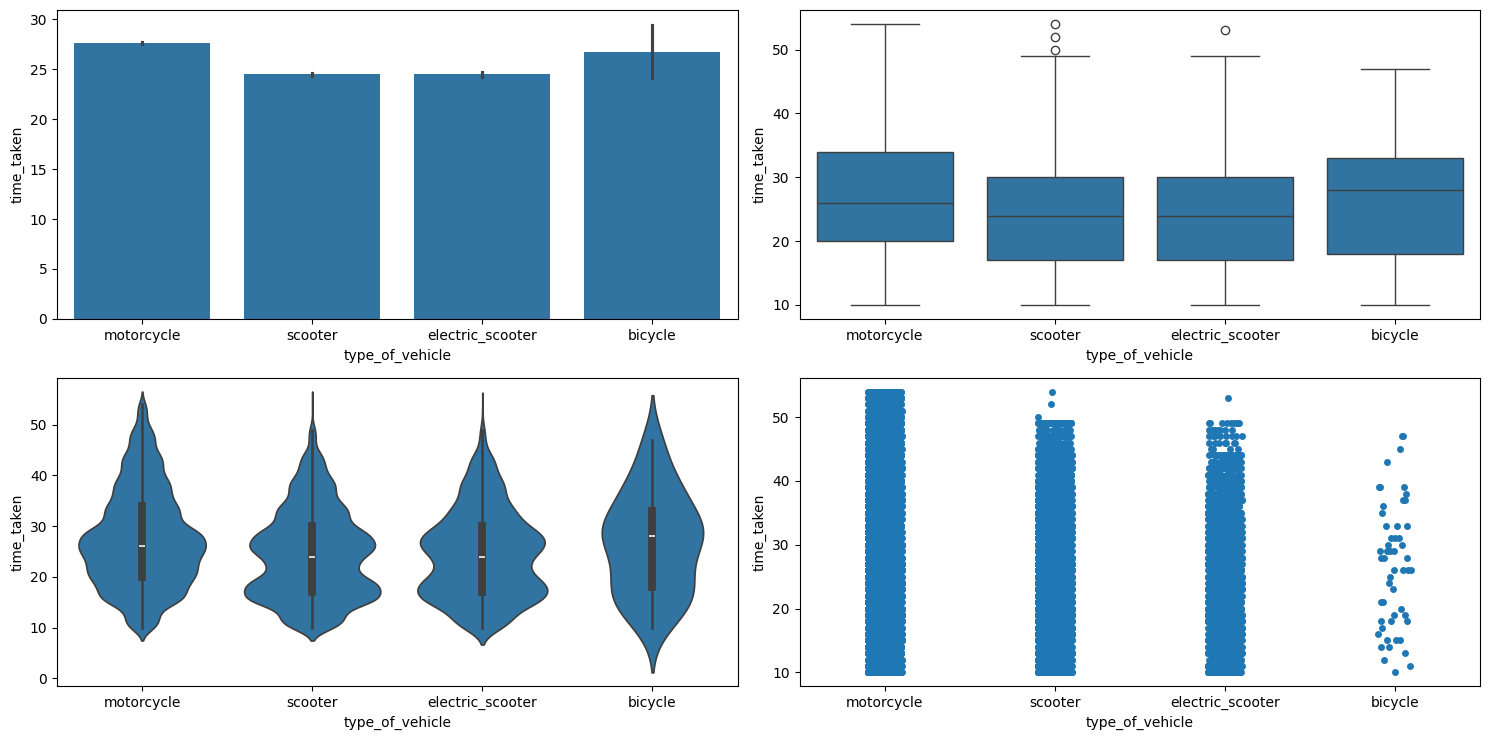

In [194]:
numerical_categorical_analysis(df_final, 'type_of_vehicle', 'time_taken')

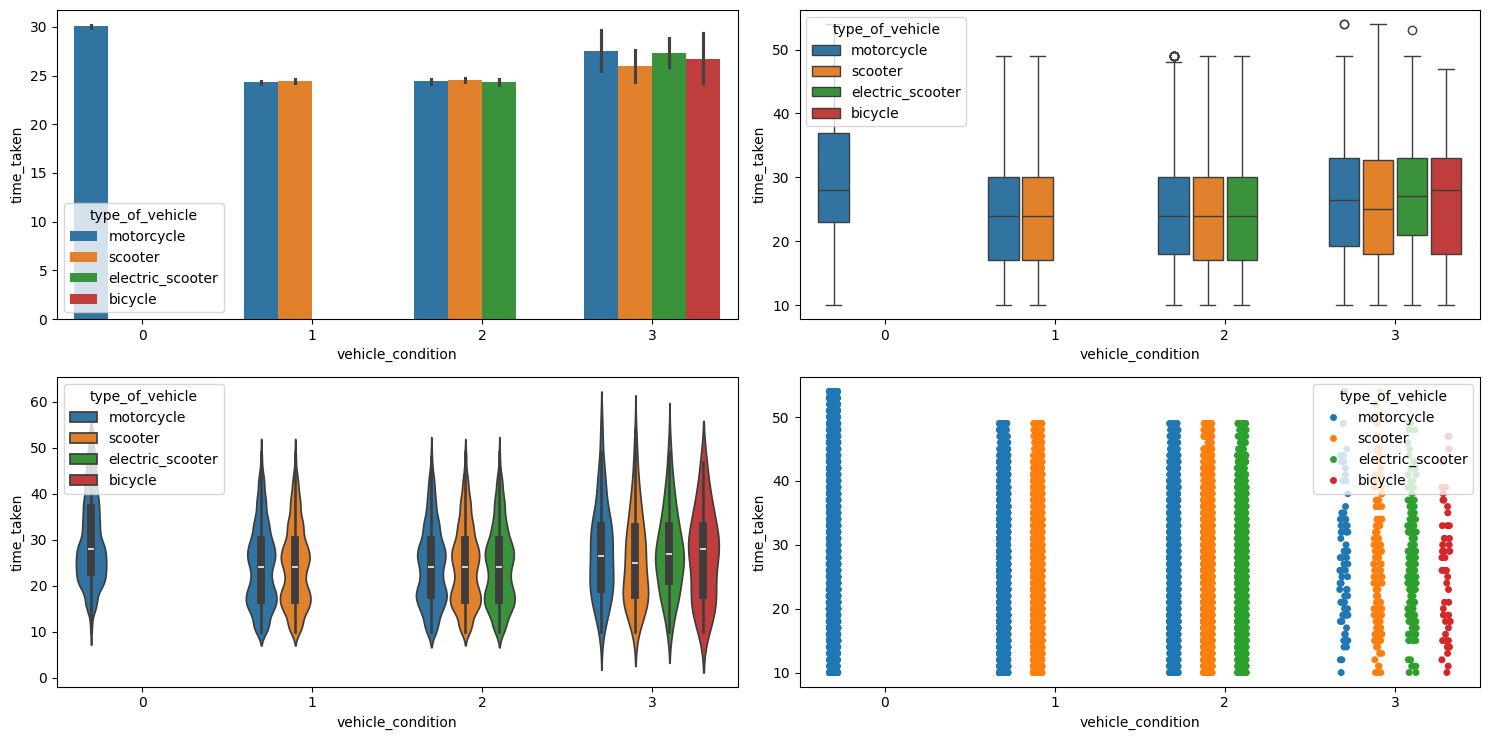

In [195]:
multivariate_analysis(df_final, 'time_taken', 'vehicle_condition', 'type_of_vehicle')

In [198]:
chi_2_test(df_final, 'type_of_vehicle', 'vehicle_condition')

0.0
reject the null hypothesis. there is a significant assosiation betweem type_of_vehicle and vehicle_condition


### type_of_order

,count,percentage
type_of_order,,
snack,11512,25.3%
meal,11435,25.13%
drinks,11294,24.82%
buffet,11261,24.75%


**************************************************
the unique categories in type_of_order columns are ['snack', 'drinks', 'buffet', 'meal']
**************************************************
the number of categories in type_of_order columns are 4


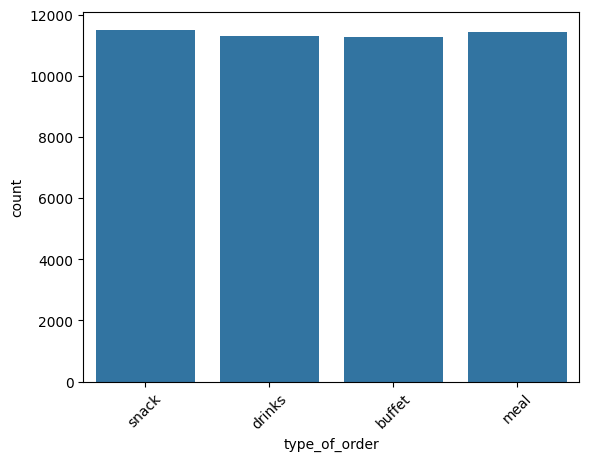

In [199]:
categorical_analysis(df_final, 'type_of_order')

<Figure size 1500x900 with 0 Axes>

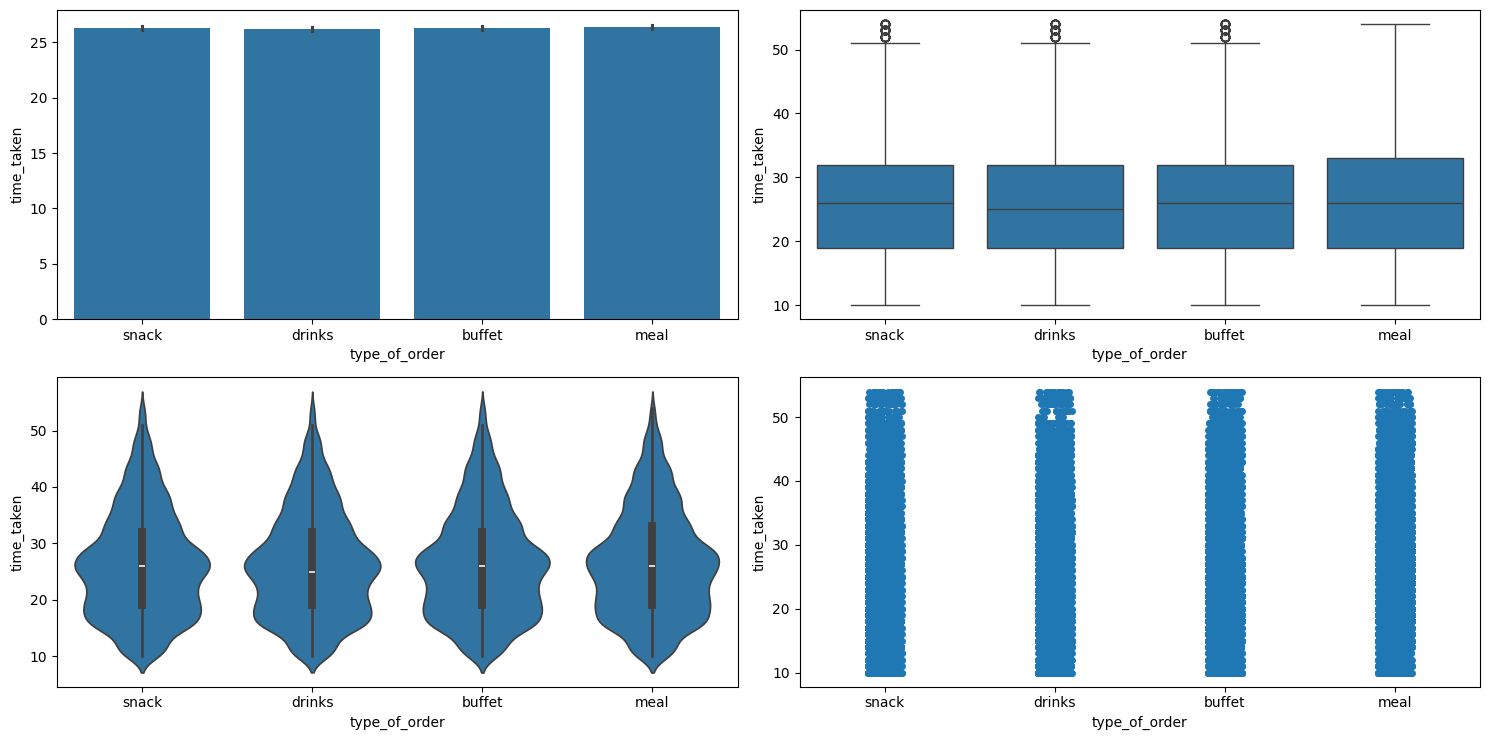

In [200]:
numerical_categorical_analysis(df_final, 'type_of_order', 'time_taken')

In [202]:
anova_test(df_final, 'time_taken', 'type_of_order')

0.3043309877239704
fail to reject the null hypothesis. there is no significant assosiation betweem time_taken and type_of_order


In [205]:
pd.crosstab(df_final['type_of_order'], df_final['is_weekend'])

is_weekend,0,1
type_of_order,,
buffet,8238,3023
drinks,8130,3164
meal,8290,3145
snack,8337,3175


In [206]:
chi_2_test(df_final, 'pickup_time_minutes', 'type_of_order')

0.49118080317709845
fail to reject the null hypothesis. there is no significant assosiation betweem pickup_time_minutes and type_of_order


<Figure size 1500x900 with 0 Axes>

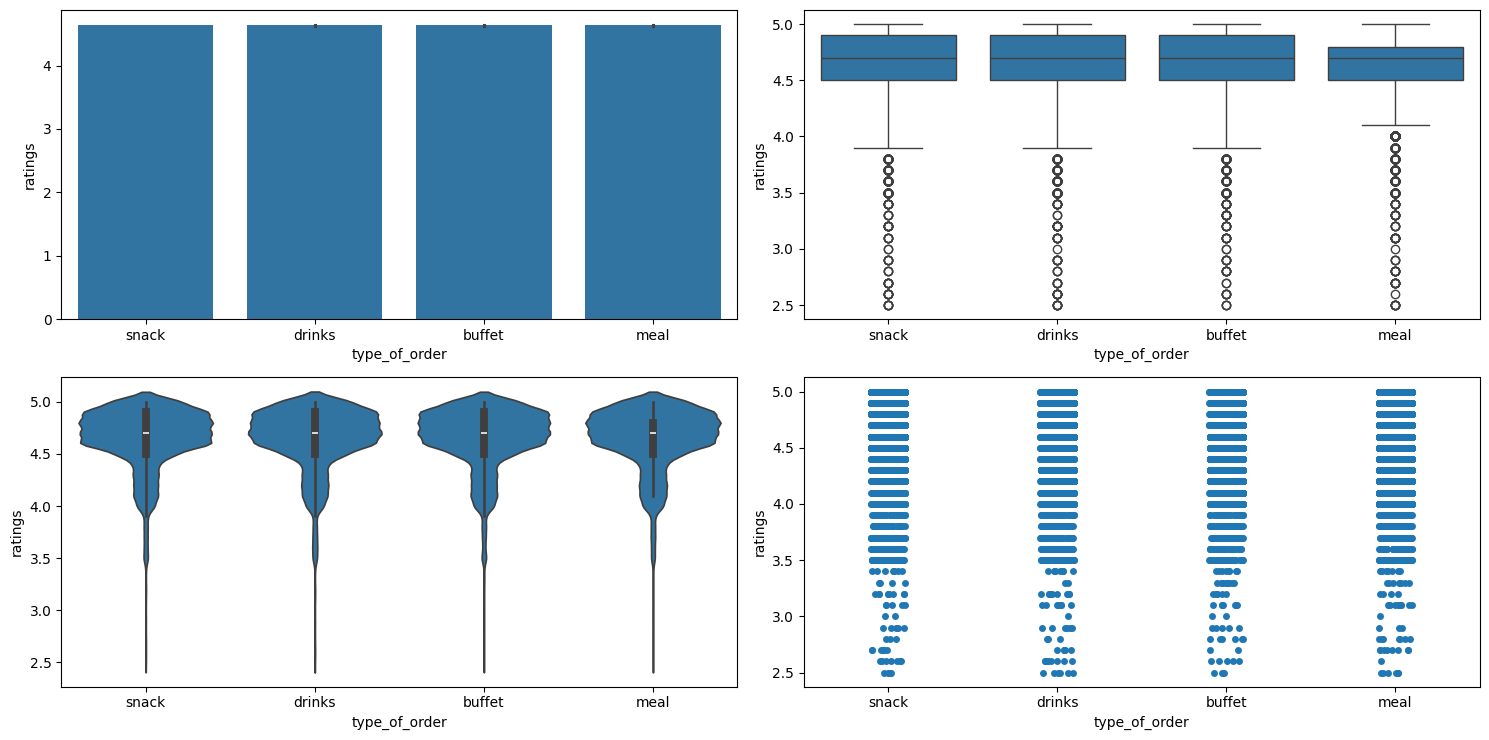

In [207]:
numerical_categorical_analysis(df_final, 'type_of_order', 'ratings')

In [208]:
chi_2_test(df_final, 'festival', 'type_of_order')

0.6149018072722126
fail to reject the null hypothesis. there is no significant assosiation betweem festival and type_of_order


In [209]:
chi_2_test(df_final, 'is_weekend', 'type_of_order')

0.2658161540207276
fail to reject the null hypothesis. there is no significant assosiation betweem is_weekend and type_of_order


### city_name

,count,percentage
city_name,,
JAP,3439,7.56%
RANCHI,3222,7.08%
BANG,3184,7.0%
SUR,3182,6.99%
HYD,3177,6.98%
MUM,3168,6.96%
MYS,3164,6.95%
COIMB,3162,6.95%
VAD,3159,6.94%


**************************************************
the unique categories in city_name columns are ['INDO', 'BANG', 'COIMB', 'CHEN', 'HYD', 'RANCHI', 'MYS', 'DEH', 'KOC', 'PUNE', 'LUDH', 'KNP', 'MUM', 'KOL', 'JAP', 'SUR', 'GOA', 'AURG', 'AGR', 'VAD', 'ALH', 'BHP']
**************************************************
the number of categories in city_name columns are 22


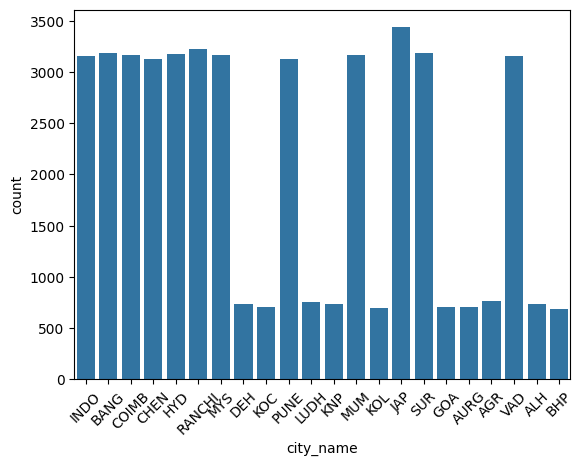

In [210]:
categorical_analysis(df_final, 'city_name')

<Figure size 1500x900 with 0 Axes>

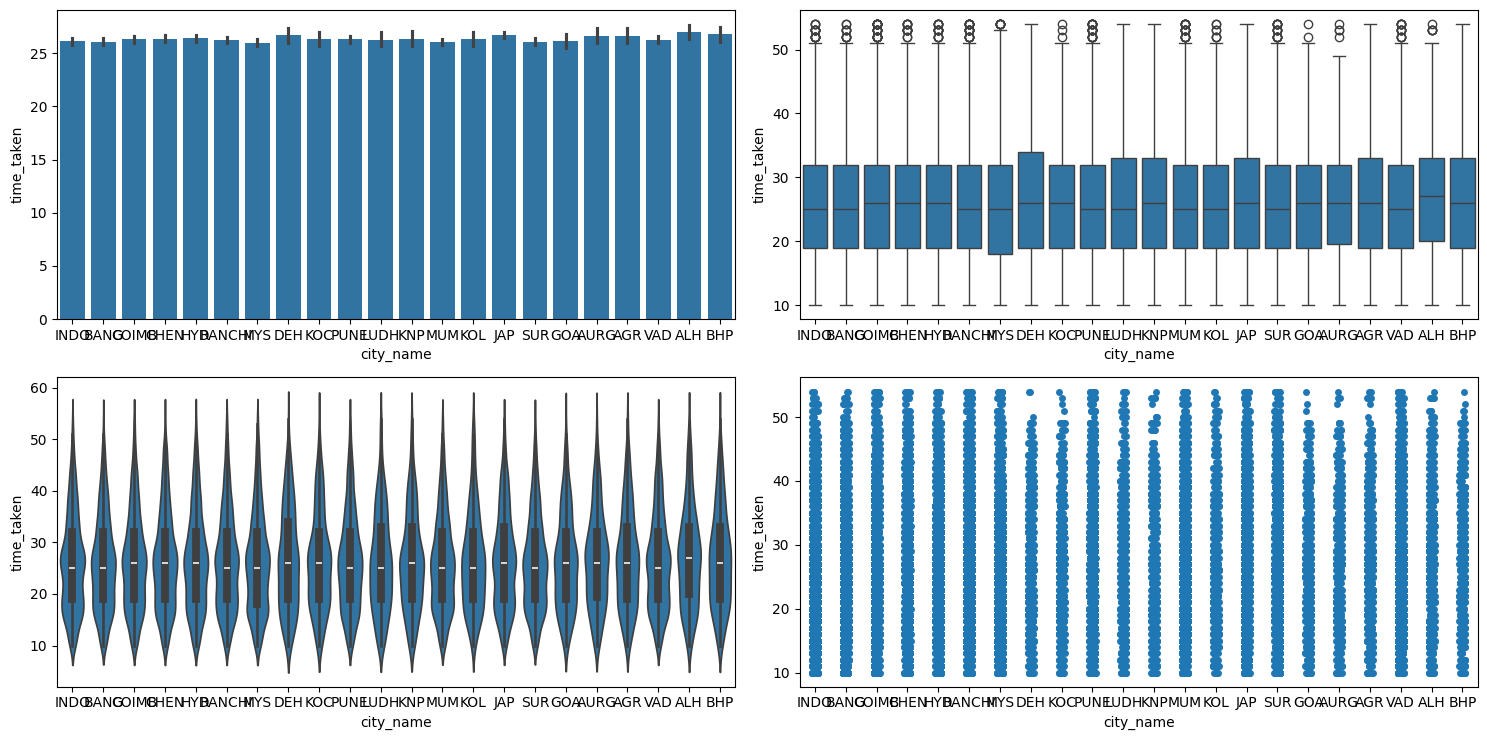

In [211]:
numerical_categorical_analysis(df_final, 'city_name', 'time_taken')

,count,percentage
city_type,,
metropolitian,34029,76.81%
urban,10111,22.82%
semi-urban,164,0.37%


**************************************************
the unique categories in city_type columns are ['urban', 'metropolitian', 'semi-urban', nan]
**************************************************
the number of categories in city_type columns are 3


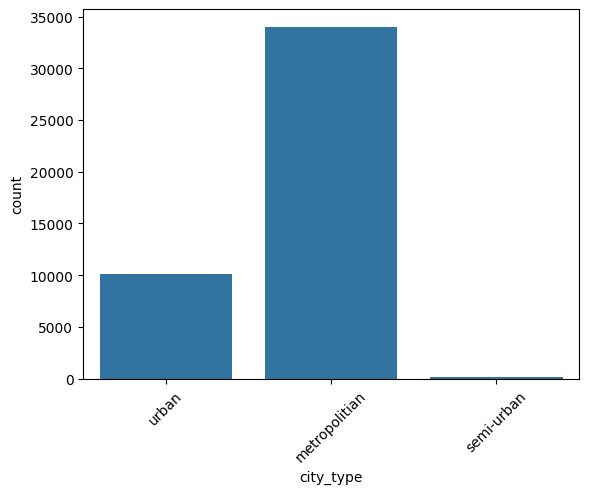

In [212]:
categorical_analysis(df_final, 'city_type')

<Figure size 1500x900 with 0 Axes>

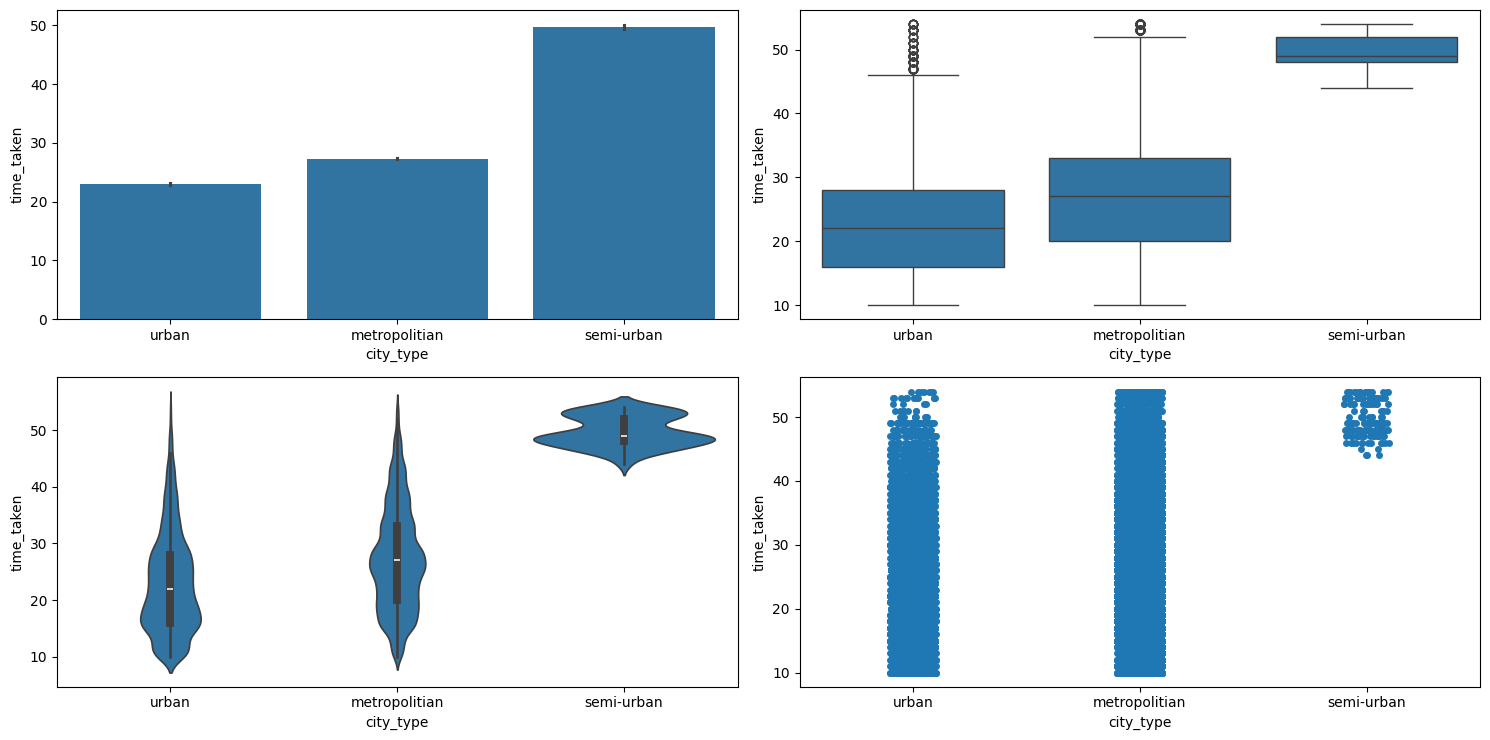

In [213]:
numerical_categorical_analysis(df_final, 'city_type', 'time_taken')

In [214]:
anova_test(df_final, 'time_taken', 'city_type')

0.0
reject the null hypothesis. there is a significant assosiation betweem time_taken and city_type


<Figure size 1500x900 with 0 Axes>

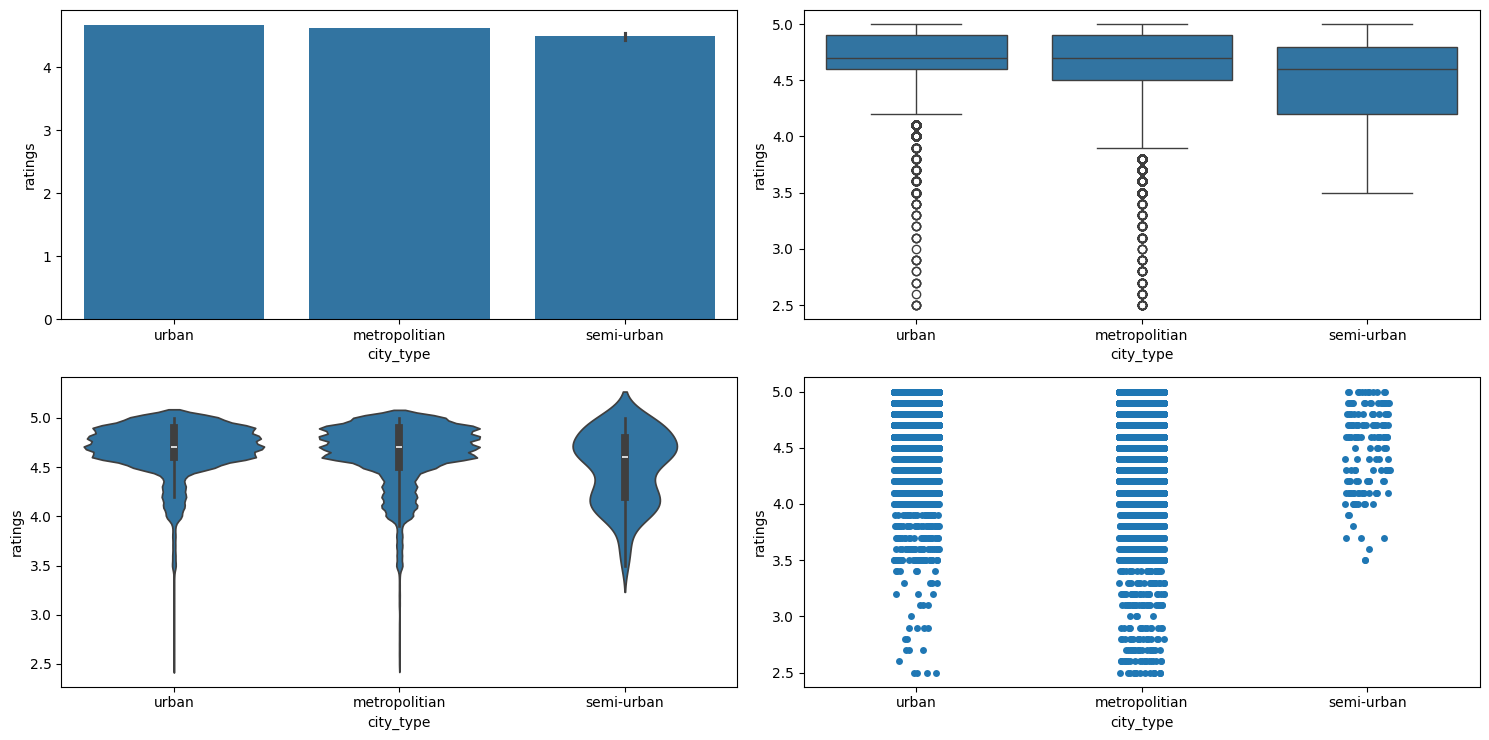

In [215]:
numerical_categorical_analysis(df_final, 'city_type', 'ratings')

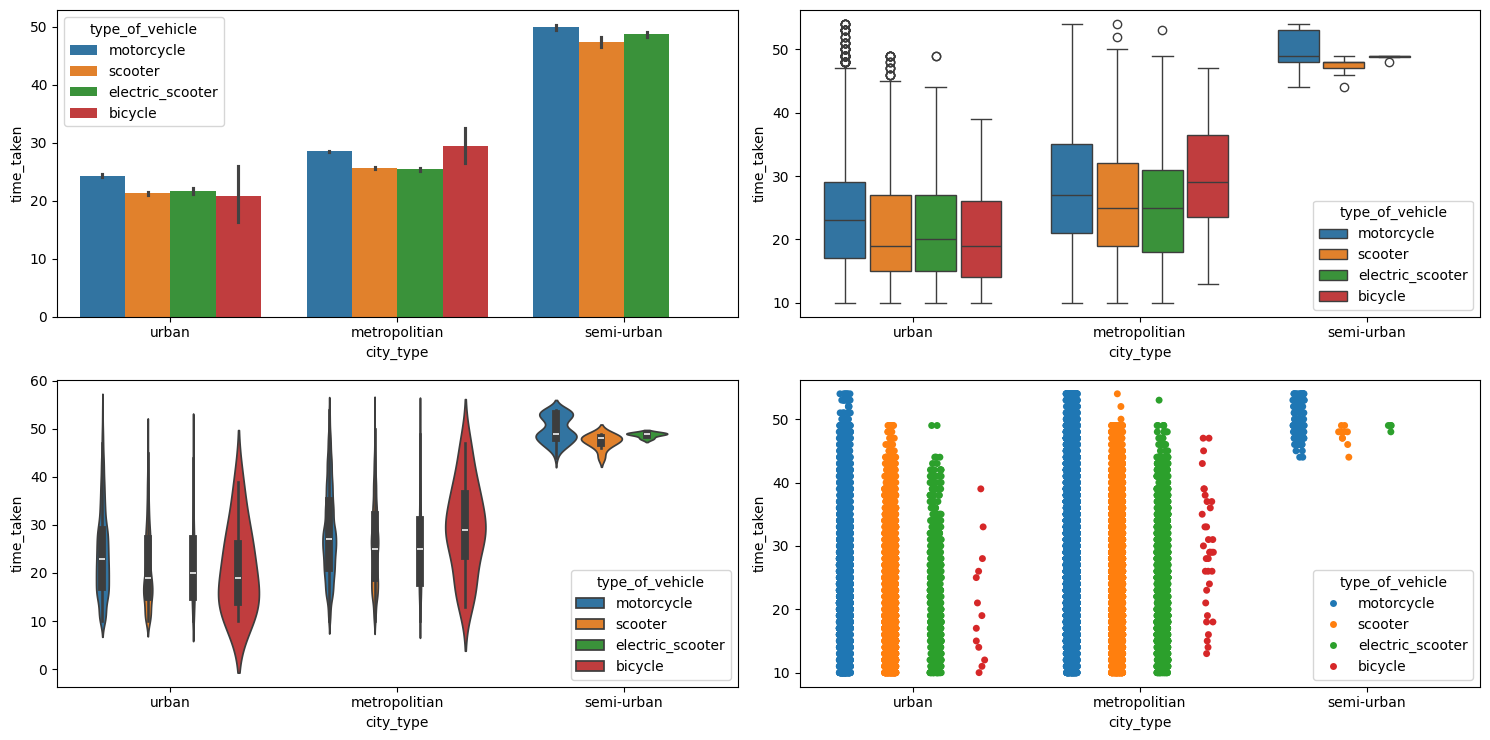

In [217]:
multivariate_analysis(df_final, 'time_taken', 'city_type', 'type_of_vehicle')

### Distance

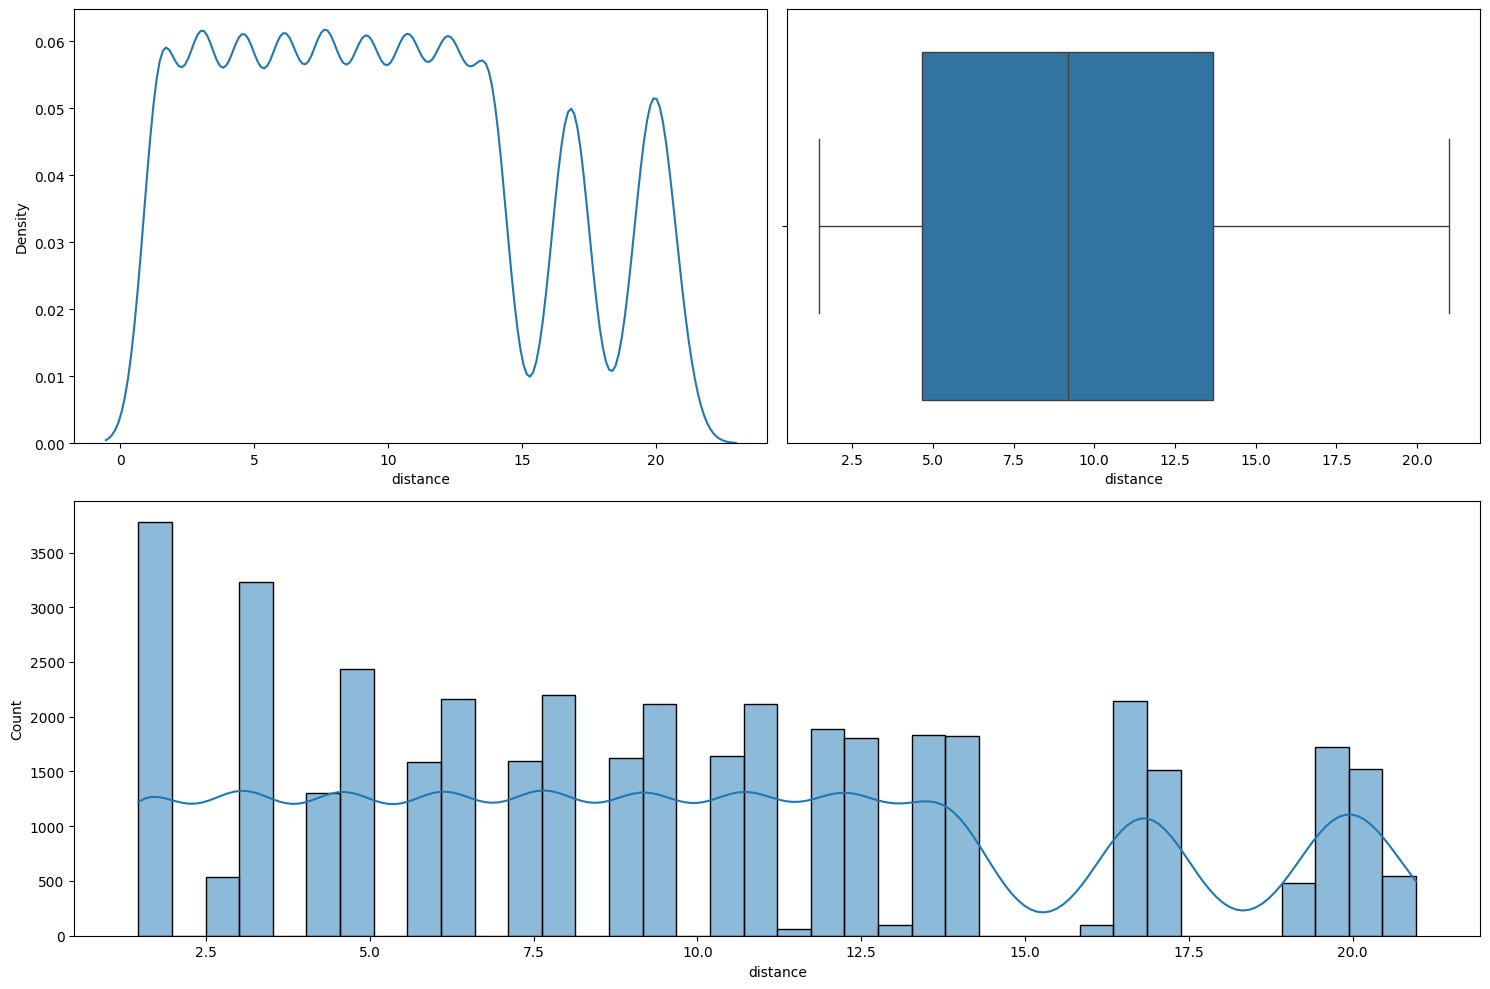

In [218]:
numerical_analysis(df_final, 'distance')

<Axes: xlabel='distance', ylabel='time_taken'>

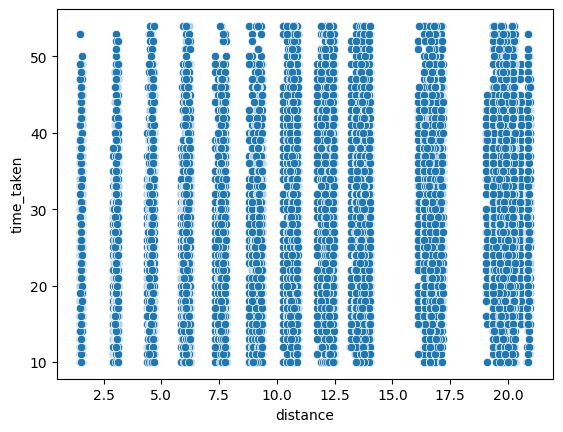

In [219]:
sns.scatterplot(df_final, x='distance', y='time_taken')

In [220]:
df_final[['distance', 'time_taken']].corr()

,distance,time_taken
distance,1.000000,0.320705
time_taken,0.320705,1.000000


<Figure size 1500x900 with 0 Axes>

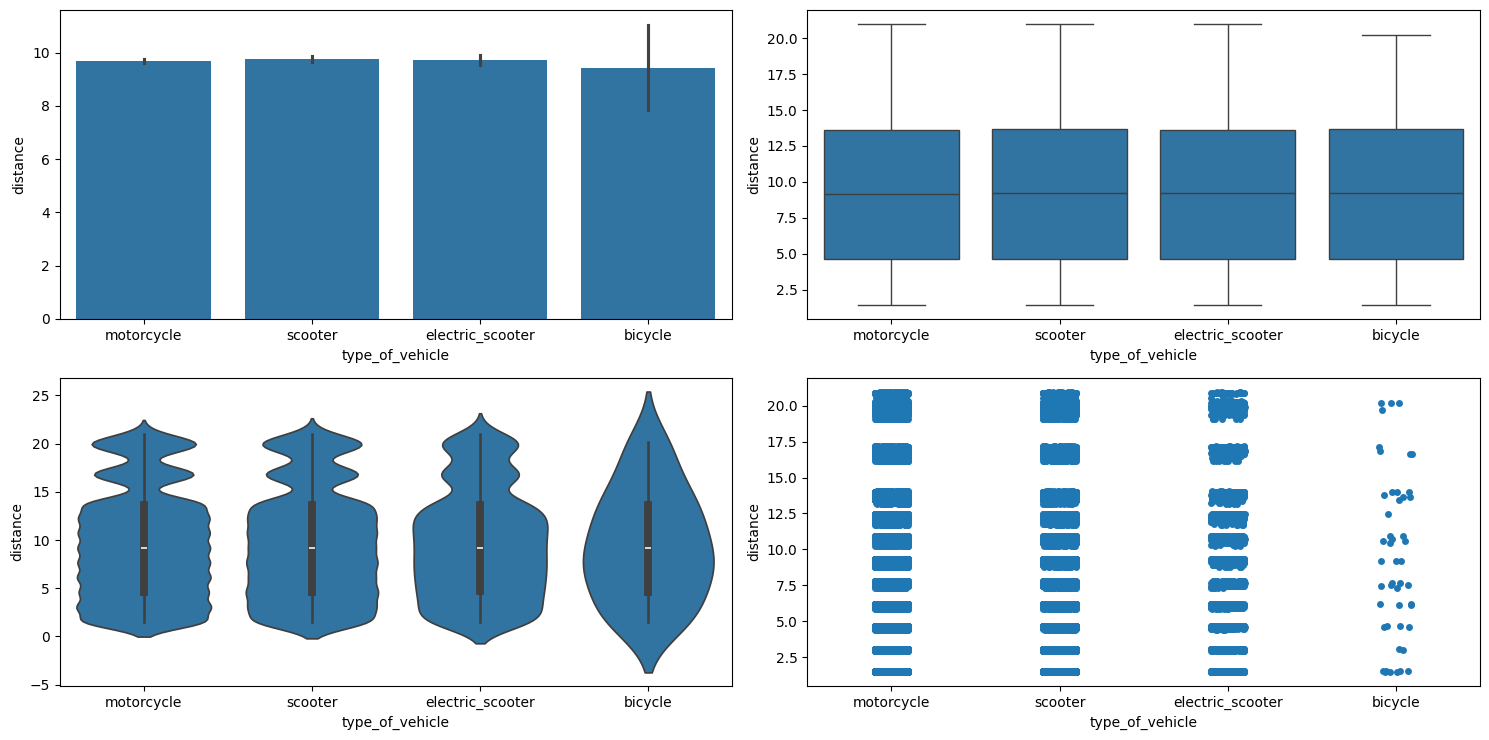

In [223]:
numerical_categorical_analysis(df_final, 'type_of_vehicle', 'distance')

<Figure size 1500x900 with 0 Axes>

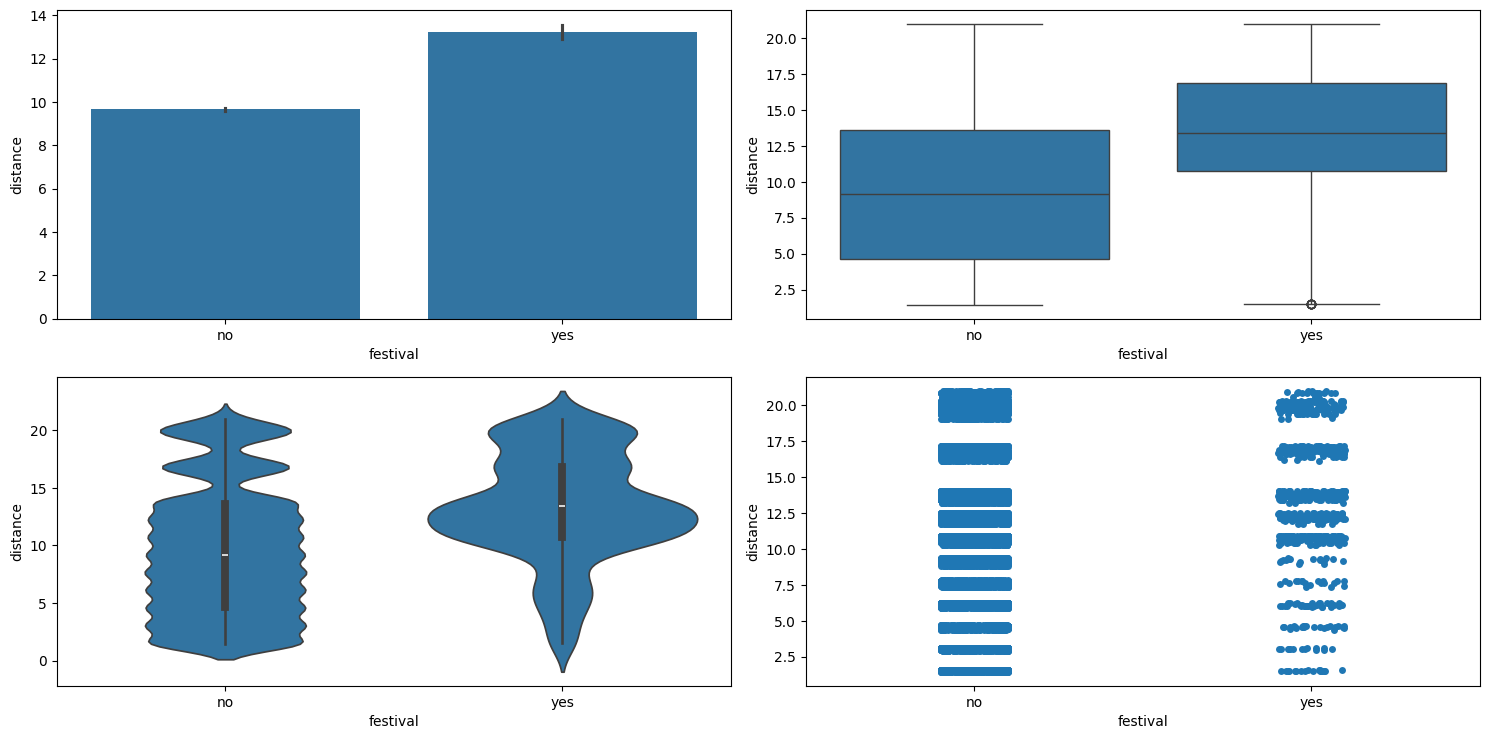

In [224]:
numerical_categorical_analysis(df_final, 'festival', 'distance')

<Figure size 1500x900 with 0 Axes>

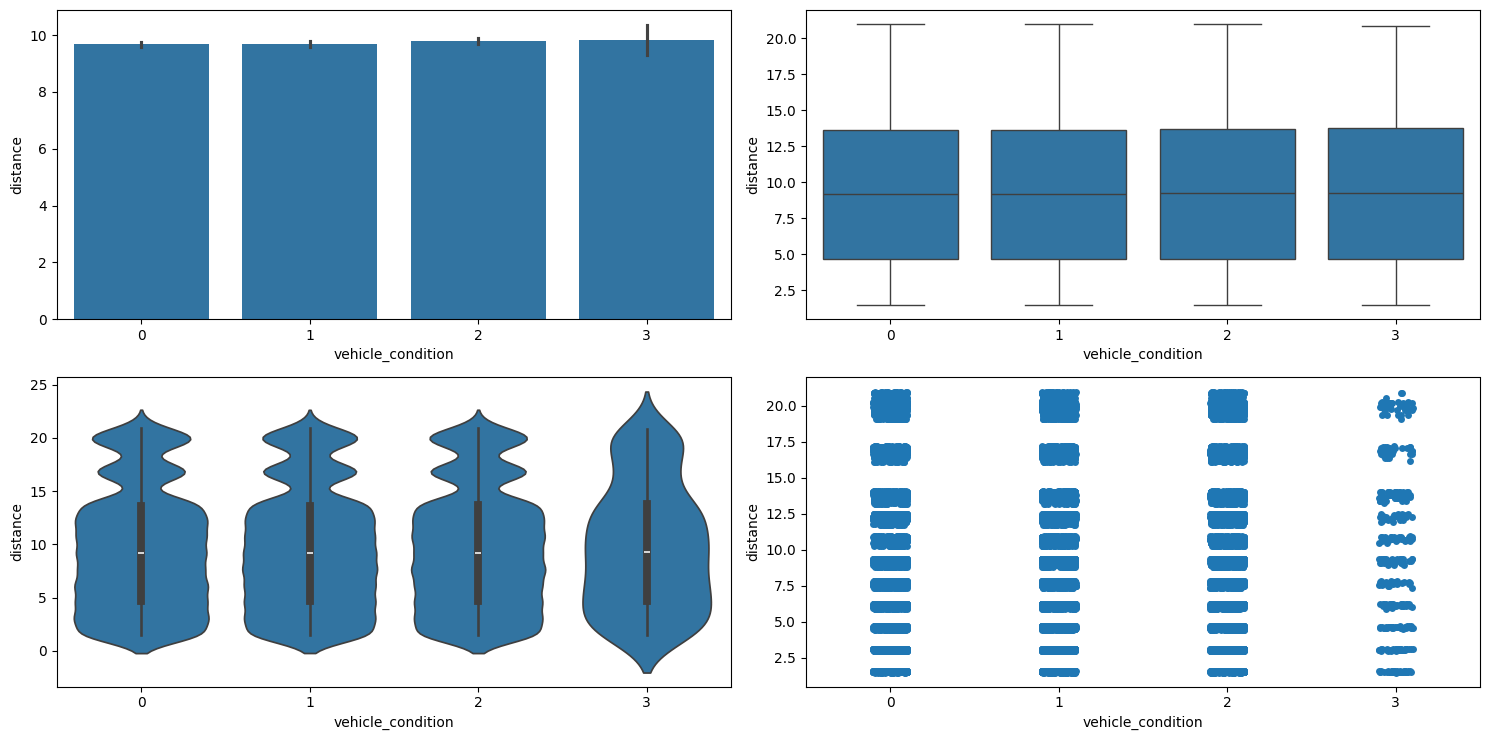

In [226]:
numerical_categorical_analysis(df_final, 'vehicle_condition', 'distance')